<a href="https://colab.research.google.com/github/WVF-1/The-Full-Monty/blob/main/FULPs_FULP1_v1_ARE_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs — FULP Version One (ARE Enhanced)

**Four targeted fixes applied to the ARE Edition.**

---

## Changes from ARE Edition

| # | Location | Change | Rationale |
|---|----------|--------|-----------|
| 1 | Config | Grid **9×9 = 81 Skepsis**, MAX_PSA_LEVELS=9 | Original intended size |
| 2 | `Skepsi.activate()` | Save **`initial_result`** snapshot before FULP 6/7 fusion | FULP 5 must learn from pre-consensus state, not post-averaging state |
| 3 | `Encephalon.predict_single()` | **Size-invariant confidence formula** | Removes the `eff_w.mean()` term that caused confidence to collapse as Symposium grew |
| 4 | Config | `ROLE_DECAY_UNTRIGGERED` 0.002→**0.0005**, `EARLY_STOP_CONTRADICTION` 0.15→**0.20** | Prevents role collapse on XL; makes contradiction resolution stop sooner |

---

## Why each fix matters

**Fix 2 — Initial result snapshot.**
After FULP 6 (Peer Review) and FULP 7 (Contradiction Resolution) run,
`result['prediction']` has drifted to the post-consensus majority.
When FULP 5 then checks which microcells agreed with `result['prediction']`,
it compares against a target that has already been moved by averaging.
A Pattern specialist who was uniquely right gets no credit — its vote is compared
to the overwritten consensus, not to the ground truth.
The fix: snapshot the raw prediction immediately after `evaluate()`, before
any FULP 6/7 modification.

**Fix 3 — Size-invariant confidence.**
Old formula: `np.max(fused) * eff_w.mean() + 0.5 * confs.mean()`
`eff_w.mean() = 1/N`, so with N=23 Skepsis it multiplies by 0.043.
Even a confident fused vector (max=0.60) scores 0.60×0.043 ≈ 0.03.
This triggers EMERGENCY_EXPAND, which adds more Skepsis, which further
lowers `eff_w.mean()`, which lowers confidence further. Runaway loop.
New formula: `np.max(fused) × (0.5 + 0.5 × agreement_rate)`
Agreement rate = fraction of Symposium pointing to the predicted class.
Size-invariant: a Symposium of 3 or 81 with the same signal gets the same score.

**Fix 4 — Decay balance.**
With `ROLE_DECAY_UNTRIGGERED=0.002` and 8 untriggered roles per sample:
each sample applies `8 × 0.002 = 0.016` total decay vs `+0.02` gain for one role.
Over 400 XL samples: net decay = 6.4 units vs net gain ≈ 4.0 units.
Roles collapse toward `ROLE_MIN` before specialization can develop.
With `ROLE_DECAY_UNTRIGGERED=0.0005`: net decay = 1.6 vs gain = 4.0. Positive.

---

**FULP 1–7**: All preserved. **Mutation (FULP 8)**: Placeholder only.


In [23]:
# ── Cell 1: Install ─────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['torch','scipy','scikit-learn','pandas','matplotlib','seaborn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'--quiet'],capture_output=True)
print('Packages ready.')


Packages ready.


In [24]:
# ── Cell 2: Imports and Configuration ───────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
OUT_DIR = '/content' if os.path.exists('/content') else '.'

# ── FIX 1: Grid — 9×9 = 81 Skepsis (original intended size) ─────────────────
GRID_H, GRID_W  = 9, 9       # changed from 5×5; maximum Symposium is now 81
MAX_PSA_LEVELS  = 4

SUBSPACE_FRAC   = 0.6

# ── Confidence / Contradiction thresholds (unchanged) ────────────────────────
CONF_ACCEPT     = 0.60
CONT_ACCEPT     = 0.35
CONF_EMERGENCY  = 0.50
CONT_EMERGENCY  = 0.30

# ── VoidStabilizer (FULP 1, unchanged) ───────────────────────────────────────
VOID_HIDDEN     = 16
EA_TARGET_STD   = 0.3
EA_WEIGHT       = 0.5
VOID_EPOCHS     = 100
VOID_BATCH      = 128
DSC_CALIBRATION_PERCENTILE = 75

# ── FULP 2: Memory EMA rates (unchanged) ─────────────────────────────────────
WORKING_EMA     = 0.6
EPISODIC_EMA    = 0.95

# ── FULP 3: Context EMA rate (unchanged) ──────────────────────────────────────
CONTEXT_ALPHA   = 0.10

# ── FULP 4: Reputation (unchanged) ───────────────────────────────────────────
REP_LR  = 0.05
REP_MIN = 0.10
REP_MAX = 2.00

# ── FULP 5: ARE constants ─────────────────────────────────────────────────────
ROLE_LR                = 0.02
ROLE_DECAY_WRONG       = 0.008
# FIX 4: reduced from 0.002 → 0.0005 to prevent role collapse on large datasets
ROLE_DECAY_UNTRIGGERED = 0.0005
ROLE_MIN               = 0.10
COOP_LR                = 0.05
COOP_MIN               = 0.00

NOVELTY_ROLE_THRESH     = 0.30
ANOMALY_ROLE_THRESH     = 0.30
UNCERTAINTY_ROLE_THRESH = 0.35
CONSENSUS_CONT_THRESH   = 0.20

ALL_ROLES = ['pattern','memory','trend','novelty','uncertainty',
             'causality','prediction','anomaly','consensus']

# ── FULP 7: Contradiction Resolution ─────────────────────────────────────────
MAX_CONTRADICTION_PASSES  = 3
# FIX 4: raised from 0.15 → 0.20 — stop earlier when disagreement is already low
EARLY_STOP_CONTRADICTION  = 0.20

# ── Microcell stubbornness defaults (unchanged) ───────────────────────────────
MICROCELL_STUBBORNNESS = {
    'pattern':0.50,'memory':0.40,'trend':0.45,'novelty':0.80,
    'uncertainty':0.50,'causality':0.55,'prediction':0.40,
    'anomaly':0.70,'consensus':0.20,
}

# ── Baselines (unchanged) ─────────────────────────────────────────────────────
RF_N_ESTIMATORS = 100
GNN_K, GNN_EPOCHS, GNN_HIDDEN, GNN_LR = 5, 100, 32, 1e-3

# ── Experiment (unchanged) ────────────────────────────────────────────────────
GLOBAL_SEED = 42
TEST_SIZE   = 0.25

# ── Plotting ─────────────────────────────────────────────────────────────────
TIER_COLORS  = {'S':'#4c72b0','M':'#55a868','L':'#c44e52','XL':'#8172b2'}
MODEL_COLORS = {'RF':'#4c72b0','GNN':'#55a868','FULP1':'#c44e52'}
ROLE_COLORS  = {
    'pattern':'#4c72b0','memory':'#55a868','trend':'#c44e52','novelty':'#8172b2',
    'uncertainty':'#ccb974','causality':'#64b5cd','prediction':'#dd8452',
    'anomaly':'#937860','consensus':'#76b900',
}
plt.rcParams.update({
    'font.family':'monospace','axes.titlesize':10,'axes.labelsize':9,
    'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,
    'axes.grid':True,'grid.alpha':0.3,
})
STATE_INACTIVE   = 'INACTIVE'
STATE_EVALUATING = 'EVALUATING'
STATE_ACCEPTED   = 'ACCEPTED'
STATE_PEER_REVIEW= 'PEER_REVIEW'
STATE_EMERGENCY  = 'EMERGENCY'

print('Configuration loaded.')
print(f'FIX 1 — Grid: {GRID_H}×{GRID_W} = {GRID_H*GRID_W} Skepsis  |  MAX_PSA_LEVELS={MAX_PSA_LEVELS}')
print(f'FIX 4 — ROLE_DECAY_UNTRIGGERED={ROLE_DECAY_UNTRIGGERED}  |  EARLY_STOP_CONTRADICTION={EARLY_STOP_CONTRADICTION}')


Configuration loaded.
FIX 1 — Grid: 9×9 = 81 Skepsis  |  MAX_PSA_LEVELS=4
FIX 4 — ROLE_DECAY_UNTRIGGERED=0.0005  |  EARLY_STOP_CONTRADICTION=0.2


In [25]:
# ── Cell 3: Synthetic Datasets (S / M / L / XL) — unchanged ─────────────────
TIER_SIZES = {'S':200,'M':400,'L':800,'XL':1600}

def _gen_S(n, rng):
    f1=rng.normal(0,1,n); f2=rng.normal(0,1,n); f3=rng.normal(0,1,n)
    score=1.5*f1-1.2*f2+0.3*f3+rng.normal(0,0.15,n)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3}),(score>0).astype(int),score

def _gen_M(n, rng):
    X,_,score=_gen_S(n,rng); f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    score_m=score+0.8*f4**2-0.5*f4*X['f2'].values+rng.normal(0,0.25,n)
    X['f1']+=rng.normal(0,0.05,n); X['f2']+=rng.normal(0,0.05,n)
    X['f4']=f4; X['f5']=f5
    return X,np.where(score_m>0.4,1,np.where(score_m<-0.4,0,2)),score_m

def _gen_L(n, rng):
    f2=rng.normal(0,1,n); f3=rng.normal(0,1,n)
    f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    f1=np.zeros(n); f1[0]=rng.normal(0,1)
    for t in range(1,n): f1[t]=0.6*f1[t-1]+0.4*rng.normal(0,1)
    f6=np.roll(f1,1); f6[0]=0.0
    sl=1.5*f1-1.2*f2+0.3*f3+0.8*f4**2-0.5*f4*f2+0.5*f1*f4+0.4*f6+rng.normal(0,0.40,n)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3,'f4':f4,'f5':f5,'f6':f6}),np.digitize(sl,np.quantile(sl,[.25,.5,.75])),sl

def _gen_XL(n, rng):
    X,_,sl=_gen_L(n,rng)
    xc=rng.uniform(0,10,n); yc=rng.uniform(0,10,n)
    centers=np.array([[2,2],[8,2],[5,8]])
    d=np.stack([np.hypot(xc-c[0],yc-c[1]) for c in centers],axis=1)
    score_xl=sl+(d.argmin(axis=1)-1.0)*1.2+rng.normal(0,0.30,n)
    y=np.digitize(score_xl,np.quantile(score_xl,[.2,.4,.6,.8]))
    contra=np.hypot(xc-5,yc-5)<1.5
    if contra.sum()>0: y[contra]=rng.integers(0,5,contra.sum())
    X['x_coord']=xc; X['y_coord']=yc
    X['f7_irrelevant']=rng.normal(0,1,n); X['f8_irrelevant']=rng.uniform(-1,1,n)
    X['contradiction_zone']=contra.astype(int)
    return X,y,score_xl

_GENERATORS={'S':_gen_S,'M':_gen_M,'L':_gen_L,'XL':_gen_XL}

def generate_dataset(tier, n=None, seed=42):
    rng=np.random.default_rng(seed); n=n or TIER_SIZES[tier]
    X,y,_=_GENERATORS[tier](n,rng)
    return X.reset_index(drop=True),np.asarray(y),int(np.unique(y).size)

for tier in ['S','M','L','XL']:
    X,y,k=generate_dataset(tier)
    print(f'{tier}: rows={len(X)} features={X.shape[1]} classes={k}')


S: rows=200 features=3 classes=2
M: rows=400 features=5 classes=3
L: rows=800 features=6 classes=4
XL: rows=1600 features=11 classes=5


In [26]:
# ── Cell 4: IDF + VoidStabilizer (FULP 1 — UNCHANGED) ───────────────────────

class InnerDepthField:
    def __init__(self, dim):
        self.dim=dim
    def _corr(self, rho):
        idx=np.arange(self.dim)
        return rho**np.abs(idx[:,None]-idx[None,:])+np.eye(self.dim)*1e-6
    def sample(self, n, rng):
        X=np.zeros((n,self.dim))
        for i in range(n):
            mu=rng.normal(0,0.02); sig=rng.uniform(0.05,0.30); rho=rng.uniform(-0.2,0.2)
            try:
                L=cholesky(self._corr(rho),lower=True)
                X[i]=mu+sig*(L@rng.normal(0,1,self.dim))
            except: X[i]=rng.normal(mu,sig,self.dim)
        return X.astype(np.float32)

class VoidStabilizer(nn.Module):
    def __init__(self, dim, hidden=VOID_HIDDEN, ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std=ea_target_std; self.ea_weight=ea_weight
        self.encoder=nn.Sequential(nn.Linear(dim,hidden),nn.Tanh())
        self.decoder=nn.Linear(hidden,dim)
    def forward(self, x):
        z=self.encoder(x); return self.decoder(z),z
    def dsc(self, x):
        x_hat,_=self.forward(x); return torch.mean((x-x_hat)**2,dim=1)
    def training_loss(self, x):
        x_hat,z=self.forward(x)
        recon=nn.functional.mse_loss(x_hat,x); ea=(z.std()-self.ea_target_std)**2
        return recon+self.ea_weight*ea,recon.item(),ea.item()

def train_void_stabilizer(dim, seed=GLOBAL_SEED, n_epochs=VOID_EPOCHS, batch_size=VOID_BATCH):
    rng=np.random.default_rng(seed); idf=InnerDepthField(dim); model=VoidStabilizer(dim)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    for _ in range(n_epochs):
        x=torch.FloatTensor(idf.sample(batch_size,rng))
        loss,_,_=model.training_loss(x)
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); return model,idf

def calibrate_dsc_threshold(void_model, idf, rng, X_scaled,
                             percentile=DSC_CALIBRATION_PERCENTILE):
    with torch.no_grad():
        real_err=void_model.dsc(torch.FloatTensor(X_scaled.astype(np.float32))).numpy()
    return float(np.percentile(real_err,percentile))

print('FULP 1 — IDF + VoidStabilizer defined (unchanged).')


FULP 1 — IDF + VoidStabilizer defined (unchanged).


In [27]:
# ── Cell 5: MicrocellBank — unchanged from ARE Edition ───────────────────────

def _full_proba(clf, x_row, n_classes):
    p=clf.predict_proba(x_row.reshape(1,-1))[0]
    out=np.zeros(n_classes)
    for c,pc in zip(clf.classes_,p): out[int(c)]=pc
    s=out.sum(); return out/s if s>0 else np.full(n_classes,1.0/n_classes)

class MicrocellBank:
    def __init__(self, feature_idx, causal_idx, void_model, dsc_threshold, seed):
        self.feature_idx=feature_idx; self.causal_idx=causal_idx
        self.void_model=void_model; self.dsc_threshold=dsc_threshold
        self.seed=seed; self.n_classes=None; self.activated=False
        self.working_memory=None; self.episodic_memory=None
        self._last_novelty=0.0; self._last_anomaly=0.0

    def fit(self, X_train, y_train, n_classes):
        self.n_classes=n_classes
        Xs=X_train[:,self.feature_idx]; Xc=X_train[:,self.causal_idx]
        self.pattern_clf   =DecisionTreeClassifier(max_depth=3,random_state=self.seed).fit(Xs,y_train)
        self.prediction_clf=RandomForestClassifier(n_estimators=5,max_depth=4,random_state=self.seed).fit(Xs,y_train)
        self.trend_clf     =LogisticRegression(max_iter=500,random_state=self.seed).fit(Xs,y_train)
        self.causality_clf =DecisionTreeClassifier(max_depth=2,random_state=self.seed).fit(Xc,y_train)
        self._anomaly_mean =Xs.mean(axis=0)
        return self

    def reset_working_memory(self):
        self.working_memory=None

    def consolidate_memory(self, final_probs):
        if self.episodic_memory is None: self.episodic_memory=final_probs.copy()
        else: self.episodic_memory=EPISODIC_EMA*self.episodic_memory+(1-EPISODIC_EMA)*final_probs

    @property
    def stubbornness(self):
        base=float(np.mean(list(MICROCELL_STUBBORNNESS.values())))
        return float(np.clip(base+0.3*self._last_novelty+0.2*self._last_anomaly,0.10,0.92))

    def evaluate(self, x_full, role_weights=None):
        self.activated=True
        n=self.n_classes
        xs=x_full[self.feature_idx]; xc=x_full[self.causal_idx]
        pattern_vote   =_full_proba(self.pattern_clf,   xs,n)
        prediction_vote=_full_proba(self.prediction_clf,xs,n)
        trend_vote     =_full_proba(self.trend_clf,     xs,n)
        causality_vote =_full_proba(self.causality_clf, xc,n)
        with torch.no_grad():
            dsc_val=float(self.void_model.dsc(torch.FloatTensor(x_full).unsqueeze(0)))
        novelty_score=float(np.clip(dsc_val/(self.dsc_threshold+1e-8)-1.0,0,1))
        novelty_vote =np.full(n,1.0/n)
        anomaly_z    =float(np.mean(np.abs(xs-self._anomaly_mean)))
        anomaly_score=float(np.clip((anomaly_z-1.0)/2.0,0,1))
        anomaly_vote =np.full(n,1.0/n)
        self._last_novelty=novelty_score; self._last_anomaly=anomaly_score
        running_avg=np.mean([pattern_vote,prediction_vote,trend_vote,causality_vote],axis=0)
        if self.working_memory is None: self.working_memory=running_avg.copy()
        else: self.working_memory=WORKING_EMA*self.working_memory+(1-WORKING_EMA)*running_avg
        memory_vote=(0.7*self.working_memory+0.3*self.episodic_memory
                     if self.episodic_memory is not None else self.working_memory.copy())
        all_votes=np.stack([pattern_vote,prediction_vote,trend_vote,
                             causality_vote,novelty_vote,anomaly_vote,memory_vote])
        if role_weights is not None:
            rw=np.array([role_weights.get('pattern',0.5),role_weights.get('prediction',0.5),
                         role_weights.get('trend',0.5),role_weights.get('causality',0.5),
                         role_weights.get('novelty',0.5),role_weights.get('anomaly',0.5),
                         role_weights.get('memory',0.5)])
            rw=rw/(rw.sum()+1e-9)
            consensus_vote=(all_votes*rw[:,None]).sum(axis=0)
        else:
            consensus_vote=all_votes.mean(axis=0)
        p=np.clip(consensus_vote,1e-9,1.0)
        entropy=-np.sum(p*np.log(p))/np.log(n)
        uncertainty_score=float(entropy)
        consensus_class=int(np.argmax(consensus_vote))
        clf_votes=[pattern_vote,prediction_vote,trend_vote,causality_vote,memory_vote]
        disagree=sum(int(np.argmax(v))!=consensus_class for v in clf_votes)
        contradiction=float(np.clip(disagree/len(clf_votes)+0.3*anomaly_score+0.3*novelty_score,0,1))
        confidence=float(np.clip(np.max(consensus_vote)*(1-0.4*uncertainty_score)*(1-0.3*novelty_score)*(1-0.2*anomaly_score),0,1))
        return {
            'probs':consensus_vote,'prediction':consensus_class,
            'confidence':confidence,'contradiction':contradiction,
            'novelty':novelty_score,'anomaly':anomaly_score,
            'uncertainty':uncertainty_score,'memory_vec':memory_vote,
            'n_microcells_run':9,
            'microcell_predictions':{
                'pattern':    int(np.argmax(pattern_vote)),
                'prediction': int(np.argmax(prediction_vote)),
                'trend':      int(np.argmax(trend_vote)),
                'causality':  int(np.argmax(causality_vote)),
                'memory':     int(np.argmax(memory_vote)),
            },
        }

print('MicrocellBank defined (unchanged from ARE Edition).')


MicrocellBank defined (unchanged from ARE Edition).


In [28]:
# ── Cell 6: Skepsi ───────────────────────────────────────────────────────────
#
# FIX 2: initial_result snapshot.
#   activate() now saves a copy of the raw evaluate() output immediately
#   before FULP 6 (Peer Review) and FULP 7 (Contradiction Resolution)
#   overwrite self.result.
#
#   update_role_vector() is called later with this snapshot so that
#   FULP 5 learning is based on what each Skepsi originally thought,
#   not on the post-consensus attribution that was previously used.
#
#   All other behaviour is identical to ARE Edition.

class Skepsi:
    """Localized expert node. FIX 2: initial_result snapshot added."""

    def __init__(self, row, col, feature_idx, causal_idx,
                 void_model, dsc_threshold, seed, base_stubbornness=None):
        self.row=row; self.col=col
        self.bank=MicrocellBank(feature_idx,causal_idx,void_model,dsc_threshold,seed)
        self.state=STATE_INACTIVE; self.result=None; self.mailbox=[]
        self.initial_result=None  # FIX 2: pre-FULP-6/7 snapshot

        self.reputation=1.0
        self.role_vector={role:0.5 for role in ALL_ROLES}
        self.cooperation=0.5

        rng_l=np.random.default_rng(seed)
        self.base_stubbornness=float(
            base_stubbornness if base_stubbornness is not None
            else np.clip(rng_l.normal(0.45,0.10),0.20,0.80))

        self.context={'samples_seen':0,'avg_confidence':0.0,
                      'avg_contradiction':0.0,'avg_novelty':0.0}

    def fit(self, X_train, y_train, n_classes):
        self.bank.fit(X_train,y_train,n_classes); return self

    @property
    def stubbornness(self):
        raw=float(np.clip(max(self.base_stubbornness,self.bank.stubbornness),0.10,0.92))
        return float(np.clip(raw*(1.0-0.35*self.cooperation),0.08,0.92))

    @property
    def dominant_role(self):
        return max(self.role_vector,key=self.role_vector.get)

    def reset(self):
        self.state=STATE_INACTIVE; self.result=None; self.mailbox=[]
        self.initial_result=None  # FIX 2: clear snapshot each sample
        self.bank.reset_working_memory()

    def activate(self, x_scaled, state=STATE_EVALUATING):
        """
        FIX 2: Snapshot the raw evaluate() output before any FULP 6/7 fusion.
        self.result will be modified by Peer Review and Contradiction Resolution.
        self.initial_result is frozen here and used by FULP 5 role learning.
        """
        self.state=state
        self.result=self.bank.evaluate(x_scaled,role_weights=self.role_vector)
        # Save the untouched snapshot immediately
        self.initial_result={
            'prediction':            self.result['prediction'],
            'probs':                 self.result['probs'].copy(),
            'confidence':            self.result['confidence'],
            'contradiction':         self.result['contradiction'],
            'novelty':               self.result['novelty'],
            'anomaly':               self.result['anomaly'],
            'uncertainty':           self.result['uncertainty'],
            'microcell_predictions': self.result['microcell_predictions'].copy(),
        }
        return self.result

    def consolidate_memory(self):
        if self.result is not None: self.bank.consolidate_memory(self.result['probs'])

    def update_context(self, result):
        n=self.context['samples_seen']
        if n==0:
            self.context.update(avg_confidence=result['confidence'],
                                avg_contradiction=result['contradiction'],
                                avg_novelty=result.get('novelty',0.0))
        else:
            a=CONTEXT_ALPHA
            self.context['avg_confidence']   =(1-a)*self.context['avg_confidence']   +a*result['confidence']
            self.context['avg_contradiction']=(1-a)*self.context['avg_contradiction']+a*result['contradiction']
            self.context['avg_novelty']      =(1-a)*self.context['avg_novelty']      +a*result.get('novelty',0.0)
        self.context['samples_seen']+=1

    def update_reputation(self, was_correct):
        target=1.5 if was_correct else 0.5
        self.reputation=float(np.clip((1-REP_LR)*self.reputation+REP_LR*target,REP_MIN,REP_MAX))

    def update_role_vector(self, result, was_correct, agreed_with_consensus):
        """
        ARE role learning. Called with initial_result (pre-FULP-6/7).
        Now compares microcell votes against the original prediction,
        not the post-consensus overwritten one.
        """
        pred         =result['prediction']
        mc_preds     =result.get('microcell_predictions',{})
        novelty      =result.get('novelty',   0.0)
        anomaly      =result.get('anomaly',   0.0)
        uncertainty  =result.get('uncertainty',1.0)
        contradiction=result.get('contradiction',1.0)
        triggered=set()

        clf_roles=['pattern','prediction','trend','causality','memory']
        for role in clf_roles:
            this_agreed=(mc_preds.get(role)==pred)
            other_agree=sum(mc_preds.get(r)==pred for r in clf_roles if r!=role)
            decisiveness=1.0-other_agree/max(len(clf_roles)-1,1)
            if was_correct and this_agreed:
                self.role_vector[role]=min(1.0,self.role_vector[role]+ROLE_LR*(0.30+0.70*decisiveness))
                triggered.add(role)
            elif not was_correct and this_agreed:
                self.role_vector[role]=max(ROLE_MIN,self.role_vector[role]-ROLE_DECAY_WRONG)

        if was_correct and novelty>NOVELTY_ROLE_THRESH:
            self.role_vector['novelty']=min(1.0,self.role_vector['novelty']+ROLE_LR); triggered.add('novelty')
        elif not was_correct and novelty>NOVELTY_ROLE_THRESH:
            self.role_vector['novelty']=max(ROLE_MIN,self.role_vector['novelty']-ROLE_DECAY_WRONG*0.5)

        if was_correct and anomaly>ANOMALY_ROLE_THRESH:
            self.role_vector['anomaly']=min(1.0,self.role_vector['anomaly']+ROLE_LR); triggered.add('anomaly')
        elif not was_correct and anomaly>ANOMALY_ROLE_THRESH:
            self.role_vector['anomaly']=max(ROLE_MIN,self.role_vector['anomaly']-ROLE_DECAY_WRONG*0.5)

        if was_correct and contradiction<CONSENSUS_CONT_THRESH and agreed_with_consensus:
            self.role_vector['consensus']=min(1.0,self.role_vector['consensus']+ROLE_LR); triggered.add('consensus')
        elif not was_correct and contradiction<CONSENSUS_CONT_THRESH:
            self.role_vector['consensus']=max(ROLE_MIN,self.role_vector['consensus']-ROLE_DECAY_WRONG)

        if was_correct and uncertainty<UNCERTAINTY_ROLE_THRESH:
            self.role_vector['uncertainty']=min(1.0,self.role_vector['uncertainty']+ROLE_LR); triggered.add('uncertainty')
        elif not was_correct and uncertainty<UNCERTAINTY_ROLE_THRESH:
            self.role_vector['uncertainty']=max(ROLE_MIN,self.role_vector['uncertainty']-ROLE_DECAY_WRONG)

        for role in ALL_ROLES:
            if role not in triggered:
                self.role_vector[role]=max(ROLE_MIN,self.role_vector[role]-ROLE_DECAY_UNTRIGGERED)

    def update_cooperation(self, was_in_peer_review, prediction_correct):
        if was_in_peer_review:
            if prediction_correct: self.cooperation=min(1.0,self.cooperation+COOP_LR)
            else: self.cooperation=max(COOP_MIN,self.cooperation-COOP_LR*0.20)

    def compose_message(self):
        if self.result is None: return None
        return {'probs':self.result['probs'].copy(),'confidence':self.result['confidence'],
                'contradiction':self.result['contradiction'],'memory_vec':self.result['memory_vec'].copy(),
                'reputation':self.reputation,'cooperation':self.cooperation}

    def receive_message(self, msg):
        if msg is not None: self.mailbox.append(msg)

    def apply_messages(self, x_scaled):
        if not self.mailbox or self.result is None: return self.result
        pairs=[(self.result['probs'],self.result['confidence']*self.reputation*(0.7+0.3*self.cooperation))]
        pairs+=[(m['probs'],m['confidence']*m.get('reputation',1.0)*(0.7+0.3*m.get('cooperation',0.5)))
                for m in self.mailbox]
        weights=np.array([w for _,w in pairs]); weights=weights/(weights.sum()+1e-9)
        fused=sum(p*w for (p,_),w in zip(pairs,weights))
        self.result['probs']=fused; self.result['prediction']=int(np.argmax(fused))
        self.result['confidence']=float(np.max(fused)*(1-0.4*self.result['uncertainty']))
        return self.result

    @property
    def is_accepted(self):
        if self.result is None: return False
        return self.result['confidence']>=CONF_ACCEPT and self.result['contradiction']<=CONT_ACCEPT

    def __repr__(self):
        return (f'Skepsi({self.row},{self.col}) rep={self.reputation:.2f} '
                f'coop={self.cooperation:.2f} dominant={self.dominant_role} state={self.state}')

print('Skepsi defined.')
print('  FIX 2: initial_result snapshot active — FULP 5 learns from pre-consensus state.')


Skepsi defined.
  FIX 2: initial_result snapshot active — FULP 5 learns from pre-consensus state.


In [29]:
# ── Cell 7: Encephalon ───────────────────────────────────────────────────────
#
# FIX 2: update_skepsi_stats() now passes sk.initial_result to
#   update_role_vector() instead of sk.result.
#
# FIX 3: Size-invariant confidence formula in predict_single().
#   Old: np.max(fused) * eff_w.mean() + 0.5 * confs.mean()
#        eff_w.mean() = 1/N → confidence collapses as Symposium grows.
#   New: np.max(fused) * (0.5 + 0.5 * agreement_rate)
#        agreement_rate = fraction of Symposium pointing to predicted class.
#        Fully size-invariant: N=5 and N=81 with same signal get same score.
#
# Everything else identical to ARE Edition.

def _vn_shell(row,col,level,H,W):
    cells=[]
    if level==0: return [(row,col)]
    for dr in range(-level,level+1):
        dc_abs=level-abs(dr)
        for dc in ([dc_abs,-dc_abs] if dc_abs!=0 else [0]):
            r,c=row+dr,col+dc
            if 0<=r<H and 0<=c<W: cells.append((r,c))
    return cells

def _vn_up_to(row,col,level,H,W):
    cells=set()
    for lv in range(level+1): cells.update(_vn_shell(row,col,lv,H,W))
    return sorted(cells)


class Encephalon:
    """
    9×9 Encephalon. Two targeted fixes applied.
    Hierarchy: Encephalon → Plato → PSA → Symposium → Peer Review → Contradiction Resolution → Consensus
    """
    def __init__(self, grid_h=GRID_H, grid_w=GRID_W, subspace_frac=SUBSPACE_FRAC,
                 void_seed=GLOBAL_SEED, seed=GLOBAL_SEED):
        self.grid_h=grid_h; self.grid_w=grid_w
        self.center=(grid_h//2,grid_w//2)
        self.subspace_frac=subspace_frac; self.seed=seed; self.void_seed=void_seed
        self.rng=np.random.default_rng(seed); self.scaler=StandardScaler()
        self.void_model=None; self.idf=None; self.dsc_threshold=None
        self.n_classes=None; self.n_features=None; self.void_dim=None
        self.grid=None; self._plato=None

    @property
    def plato(self): return self._plato

    def _build_grid(self):
        n=self.n_features; n_sub=max(1,int(n*self.subspace_frac))
        causal=[0,1] if n>=2 else [0]; grid=[]
        for r in range(self.grid_h):
            row=[]
            for c in range(self.grid_w):
                sub=sorted(set(self.rng.choice(n,n_sub,replace=False).tolist())|set(causal))
                seed=int(self.rng.integers(0,1_000_000))
                row.append(Skepsi(r,c,sub,causal,self.void_model,self.dsc_threshold,seed))
            grid.append(row)
        cr,cc=self.center; self._plato=grid[cr][cc]
        return grid

    def fit(self, X_df, y, n_classes, verbose=True):
        X_raw=X_df.values.astype(np.float32)
        self.n_features=X_raw.shape[1]; self.n_classes=n_classes; self.void_dim=self.n_features
        if verbose: print('  [Enc] Training VoidStabilizer (FULP 1)…')
        self.void_model,self.idf=train_void_stabilizer(self.void_dim,seed=self.void_seed)
        rng_cal=np.random.default_rng(self.void_seed)
        X_scaled=self.scaler.fit_transform(X_raw).astype(np.float32)
        self.dsc_threshold=calibrate_dsc_threshold(self.void_model,self.idf,rng_cal,X_scaled)
        if verbose: print(f'  [Enc] DSC threshold (p{DSC_CALIBRATION_PERCENTILE}): {self.dsc_threshold:.4f}')
        self.grid=self._build_grid()
        if verbose: print(f'  [Enc] Fitting {self.grid_h*self.grid_w} Skepsis…')
        for r in range(self.grid_h):
            for c in range(self.grid_w): self.grid[r][c].fit(X_scaled,y,n_classes)
        if verbose: print(f'  [Enc] Plato: {self._plato}')
        if verbose: print('  [Enc] Encephalon ready.')
        return self

    def _cell(self,r,c): return self.grid[r][c]

    def peer_review_pass(self, active_set, x_sc):
        """FULP 6 — unchanged."""
        for (r,c) in active_set: self._cell(r,c).mailbox=[]
        for (r,c) in active_set:
            msg=self._cell(r,c).compose_message()
            for (nr,nc) in _vn_shell(r,c,1,self.grid_h,self.grid_w):
                if (nr,nc) in active_set: self._cell(nr,nc).receive_message(msg)
        for (r,c) in active_set: self._cell(r,c).apply_messages(x_sc)

    def resolve_contradictions(self, active_set):
        """FULP 7 — unchanged logic; stubbornness is cooperation-adjusted via property."""
        passes_used=0
        for _ in range(MAX_CONTRADICTION_PASSES):
            passes_used+=1
            active_results=[(r,c,self._cell(r,c).result)
                            for (r,c) in active_set if self._cell(r,c).result is not None]
            if not active_results: break
            eff_w=np.array([res['confidence']*self._cell(r,c).reputation
                            for r,c,res in active_results])
            eff_w=eff_w/(eff_w.sum()+1e-9)
            majority_probs=sum(res['probs']*w for (_,_,res),w in zip(active_results,eff_w))
            for r,c,res in active_results:
                stub=self._cell(r,c).stubbornness
                new_p=(1-stub)*majority_probs+stub*res['probs']
                new_p=new_p/(new_p.sum()+1e-9)
                res['probs']=new_p; res['prediction']=int(np.argmax(new_p))
                res['confidence']=float(np.clip(res['confidence']*(0.85+0.30*float(np.dot(new_p,majority_probs))),0,1))
            all_preds=[res['prediction'] for _,_,res in active_results]
            majority_pred=Counter(all_preds).most_common(1)[0][0]
            if sum(p!=majority_pred for p in all_preds)/len(all_preds)<EARLY_STOP_CONTRADICTION:
                break
        return passes_used

    def predict_single(self, x_raw):
        x_sc=self.scaler.transform(x_raw.reshape(1,-1))[0].astype(np.float32)
        for r in range(self.grid_h):
            for c in range(self.grid_w): self._cell(r,c).reset()
        log={'psa_expansions':0,'peer_review_activations':0,'contradiction_passes':0,
             'active_skepsis_history':[],'confidence_history':[],'contradiction_history':[],
             'state_transitions':[],'active_cells':[],'symposium_size_history':[]}
        active_set=set(); prev_conf,prev_cont=0.0,1.0
        final_result=None; cr,cc=self.center

        for level in range(1,MAX_PSA_LEVELS+1):
            target_cells=_vn_up_to(cr,cc,level-1,self.grid_h,self.grid_w)
            new_cells=[p for p in target_cells if p not in active_set]
            if new_cells:
                log['psa_expansions']+=(1 if level>1 else 0)
                for (r,c) in new_cells:
                    is_plato=(r==cr and c==cc)
                    self._cell(r,c).activate(x_sc,STATE_EVALUATING if is_plato else STATE_PEER_REVIEW)
                    if level>1: log['peer_review_activations']+=1
                    active_set.add((r,c))
                log['state_transitions'].append({
                    'level':level,'event':'PSA_init' if level==1 else 'PSA_expand',
                    'n_active':len(active_set)})

            if level>1 and active_set: self.peer_review_pass(active_set,x_sc)
            if active_set: log['contradiction_passes']+=self.resolve_contradictions(active_set)

            results=[self._cell(r,c).result for (r,c) in active_set
                     if self._cell(r,c).result is not None]
            if not results: continue

            # ── FIX 3: Size-invariant confidence ─────────────────────────
            # Old formula: np.max(fused)*eff_w.mean() + 0.5*confs.mean()
            #   eff_w.mean() = 1/N causes collapse as Symposium grows.
            # New formula: np.max(fused) * (0.5 + 0.5 * agreement_rate)
            #   agreement_rate = fraction of Symposium pointing to predicted class.
            #   N=5 or N=81 with equal signal gives equal confidence.
            eff_w=np.array([self._cell(r,c).result['confidence']*self._cell(r,c).reputation
                            for (r,c) in active_set if self._cell(r,c).result is not None])
            conts=np.array([res['contradiction'] for res in results])
            all_probs=np.stack([res['probs'] for res in results])
            eff_w=eff_w/(eff_w.sum()+1e-9)
            fused=(all_probs*eff_w[:,None]).sum(axis=0)
            final_pred=int(np.argmax(fused))

            agreement=float(np.mean([int(np.argmax(res['probs'])==final_pred)
                                     for res in results]))
            agg_conf =float(np.clip(np.max(fused)*(0.5+0.5*agreement),0,1))
            agg_cont =float(conts.mean())

            log['active_skepsis_history'].append((level,len(active_set)))
            log['confidence_history'].append(agg_conf)
            log['contradiction_history'].append(agg_cont)
            log['symposium_size_history'].append(len(active_set))
            final_result=dict(prediction=final_pred,probs=fused,
                              confidence=agg_conf,contradiction=agg_cont,
                              level=level,n_active=len(active_set))

            if agg_conf>=CONF_ACCEPT and agg_cont<=CONT_ACCEPT:
                log['state_transitions'].append({
                    'level':level,'event':'ACCEPTED',
                    'confidence':agg_conf,'contradiction':agg_cont}); break

            if agg_conf<CONF_EMERGENCY or agg_cont>CONT_EMERGENCY:
                log['state_transitions'].append({
                    'level':level,'event':'EMERGENCY_EXPAND',
                    'confidence':agg_conf,'contradiction':agg_cont})

            if level>2 and abs(agg_conf-prev_conf)<0.01 and abs(agg_cont-prev_cont)<0.01:
                log['state_transitions'].append({
                    'level':level,'event':'PLATEAU_STOP',
                    'confidence':agg_conf,'contradiction':agg_cont}); break

            if len(active_set)==self.grid_h*self.grid_w:
                log['state_transitions'].append({
                    'level':level,'event':'FULL_GRID',
                    'confidence':agg_conf,'contradiction':agg_cont}); break

            prev_conf,prev_cont=agg_conf,agg_cont

        for (r,c) in active_set:
            sk=self._cell(r,c); sk.consolidate_memory()
            if sk.result is not None: sk.update_context(sk.result)

        log['active_cells']=sorted(active_set); log['n_active_final']=len(active_set)
        log['n_microcells_final']=len(active_set)*9; log['symposium_final_size']=len(active_set)
        if final_result:
            log.update(prediction=final_result['prediction'],confidence=final_result['confidence'],
                       contradiction=final_result['contradiction'],final_level=final_result['level'])
        else:
            log.update(prediction=0,confidence=0.0,contradiction=1.0,final_level=0)
        return log

    def predict(self, X_df):
        X_raw=X_df.values.astype(np.float32)
        logs=[self.predict_single(X_raw[i]) for i in range(len(X_raw))]
        return np.array([lg['prediction'] for lg in logs]),logs

    def update_skepsi_stats(self, all_logs, y_true, y_pred):
        """
        FIX 2: passes sk.initial_result (not sk.result) to update_role_vector().
        FULP 5 now learns from what each Skepsi originally thought,
        before FULP 6 and FULP 7 modified the prediction.
        """
        for lg,y_t,y_p in zip(all_logs,y_true,y_pred):
            was_in_peer_review=(lg.get('final_level',1)>1)
            prediction_correct=(y_p==y_t)
            for (r,c) in lg.get('active_cells',[]):
                sk=self._cell(r,c)
                if sk.result is None: continue
                sk_correct =(sk.result['prediction']==y_t)
                agreed     =(sk.result['prediction']==y_p)
                sk.update_reputation(sk_correct)
                # FIX 2: use initial_result for role attribution
                learn_from=sk.initial_result if sk.initial_result is not None else sk.result
                sk.update_role_vector(learn_from,sk_correct,agreed)
                sk.update_cooperation(was_in_peer_review,prediction_correct)

    def mutate(self): pass  # FULP 8 placeholder

    # ── Heatmaps ─────────────────────────────────────────────────────────
    def activation_heatmap(self, all_logs):
        hm=np.zeros((self.grid_h,self.grid_w),dtype=int)
        for lg in all_logs:
            for (r,c) in lg.get('active_cells',[]): hm[r,c]+=1
        return hm

    def reputation_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].reputation
        return hm

    def cooperation_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].cooperation
        return hm

    def stubbornness_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].base_stubbornness
        return hm

    def role_vector_mean(self):
        return {role:float(np.mean([self.grid[r][c].role_vector[role]
                                    for r in range(self.grid_h) for c in range(self.grid_w)]))
                for role in ALL_ROLES}

    def role_vector_std(self):
        return {role:float(np.std([self.grid[r][c].role_vector[role]
                                   for r in range(self.grid_h) for c in range(self.grid_w)]))
                for role in ALL_ROLES}

    def dominant_role_grid(self):
        return [[self.grid[r][c].dominant_role for c in range(self.grid_w)]
                for r in range(self.grid_h)]

    def role_strength_heatmap(self, role):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].role_vector[role]
        return hm


print('Encephalon defined.')
print(f'  FIX 2: update_skepsi_stats uses initial_result for FULP 5 learning.')
print(f'  FIX 3: size-invariant confidence formula active.')
print(f'  Grid: {GRID_H}×{GRID_W} = {GRID_H*GRID_W} Skepsis  |  MAX_PSA_LEVELS={MAX_PSA_LEVELS}')


Encephalon defined.
  FIX 2: update_skepsi_stats uses initial_result for FULP 5 learning.
  FIX 3: size-invariant confidence formula active.
  Grid: 9×9 = 81 Skepsis  |  MAX_PSA_LEVELS=4


In [30]:
# ── Cell 8: Random Forest Baseline (unchanged) ───────────────────────────────
def train_rf(X_train, y_train, n_estimators=RF_N_ESTIMATORS, seed=GLOBAL_SEED):
    rf=RandomForestClassifier(n_estimators=n_estimators,random_state=seed,n_jobs=-1)
    rf.fit(X_train.values,y_train); return rf
print('RF baseline defined.')


RF baseline defined.


In [31]:
# ── Cell 9: GNN Baseline (unchanged) ────────────────────────────────────────
class GNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__(); self.lin=nn.Linear(in_dim*2,out_dim)
    def forward(self, h, agg_h):
        return torch.relu(self.lin(torch.cat([h,agg_h],dim=-1)))

class GNNClassifier:
    def __init__(self, k=GNN_K, hidden_dim=GNN_HIDDEN, n_epochs=GNN_EPOCHS, lr=GNN_LR, seed=GLOBAL_SEED):
        self.k=k; self.hidden_dim=hidden_dim; self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
        self.scaler=StandardScaler()
    def _agg(self,Xs,Xt,k):
        nn_m=NearestNeighbors(n_neighbors=min(k,len(Xs))).fit(Xs)
        idx=nn_m.kneighbors(Xt,return_distance=False)
        return np.stack([Xs[i].mean(0) for i in idx]).astype(np.float32)
    def fit(self,X_df,y):
        torch.manual_seed(self.seed); X=self.scaler.fit_transform(X_df.values).astype(np.float32)
        self._Xtr=X; n_f=X.shape[1]; n_cls=len(np.unique(y))
        nn_m=NearestNeighbors(n_neighbors=min(self.k+1,len(X))).fit(X)
        idx=nn_m.kneighbors(X,return_distance=False)[:,1:]
        agg=np.stack([X[i].mean(0) for i in idx]).astype(np.float32)
        h=torch.FloatTensor(X); agg_h=torch.FloatTensor(agg); y_t=torch.LongTensor(y)
        self.l1=GNNLayer(n_f,self.hidden_dim); self.l2=GNNLayer(self.hidden_dim,self.hidden_dim)
        self.head=nn.Linear(self.hidden_dim,n_cls)
        params=list(self.l1.parameters())+list(self.l2.parameters())+list(self.head.parameters())
        opt=torch.optim.Adam(params,lr=self.lr); ce=nn.CrossEntropyLoss()
        for _ in range(self.n_epochs):
            h1=self.l1(h,agg_h); agg2=torch.stack([h1[idx[i]].mean(0) for i in range(len(X))])
            h2=self.l2(h1,agg2); loss=ce(self.head(h2),y_t)
            opt.zero_grad(); loss.backward(); opt.step()
        return self
    def predict(self,X_df):
        X=self.scaler.transform(X_df.values).astype(np.float32); agg=self._agg(self._Xtr,X,self.k)
        h=torch.FloatTensor(X)
        with torch.no_grad():
            h1=self.l1(h,torch.FloatTensor(agg))
            h1_tr=self.l1(torch.FloatTensor(self._Xtr),torch.FloatTensor(self._agg(self._Xtr,self._Xtr,self.k)))
            agg2=self._agg(h1_tr.numpy(),h1.numpy(),self.k)
            h2=self.l2(h1,torch.FloatTensor(agg2))
            return torch.argmax(self.head(h2),dim=1).numpy()
print('GNN baseline defined.')


GNN baseline defined.


In [32]:
# ── Cell 10: Metrics (unchanged from ARE Edition) ────────────────────────────
def _avg_m(k): return 'macro' if k>2 else 'binary'

def clf_metrics(y_true, y_pred):
    k=len(np.unique(y_true))
    return {'accuracy':accuracy_score(y_true,y_pred),
            'precision':precision_score(y_true,y_pred,average=_avg_m(k),zero_division=0),
            'recall':recall_score(y_true,y_pred,average=_avg_m(k),zero_division=0),
            'f1':f1_score(y_true,y_pred,average=_avg_m(k),zero_division=0)}

def _final_state(log):
    events=[t['event'] for t in log.get('state_transitions',[])]
    for s in ['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND']:
        if s in events: return s
    return 'UNKNOWN'

def encephalon_metrics(y_true, y_pred, all_logs, enc):
    base=clf_metrics(y_true,y_pred)
    confs=np.array([lg['confidence'] for lg in all_logs])
    conts=np.array([lg['contradiction'] for lg in all_logs])
    acts =np.array([lg['n_active_final'] for lg in all_logs])
    pr_act=sum(lg['peer_review_activations'] for lg in all_logs)
    psa_ex=sum(lg['psa_expansions'] for lg in all_logs)
    levels=[lg.get('final_level',1) for lg in all_logs]
    sym_sz=np.array([lg.get('symposium_final_size',lg['n_active_final']) for lg in all_logs])
    cont_ps=np.array([lg.get('contradiction_passes',0) for lg in all_logs])
    sc=Counter(_final_state(lg) for lg in all_logs)
    rep_vals =[enc.grid[r][c].reputation    for r in range(enc.grid_h) for c in range(enc.grid_w)]
    coop_vals=[enc.grid[r][c].cooperation   for r in range(enc.grid_h) for c in range(enc.grid_w)]
    rv_means =enc.role_vector_mean(); rv_stds=enc.role_vector_std()
    base.update({
        'avg_confidence':float(confs.mean()),'avg_contradiction':float(conts.mean()),
        'final_state':sc.most_common(1)[0][0],'state_counts':dict(sc),
        'total_active_skepsis':int(acts.sum()),'avg_active_skepsis':float(acts.mean()),
        'peer_review_activations':pr_act,'psa_expansions':psa_ex,
        'avg_psa_level':float(np.mean(levels)),
        'accuracy_per_skepsi':float(base['accuracy']/(acts.mean()+1e-9)),
        'avg_symposium_size':float(sym_sz.mean()),
        'avg_contradiction_passes':float(cont_ps.mean()),
        'rep_mean':float(np.mean(rep_vals)),'rep_std':float(np.std(rep_vals)),
        'coop_mean':float(np.mean(coop_vals)),'coop_std':float(np.std(coop_vals)),
        'role_means':rv_means,'role_stds':rv_stds,
        'dominant_role_counts':Counter(
            enc.grid[r][c].dominant_role
            for r in range(enc.grid_h) for c in range(enc.grid_w)),
    })
    return base

def build_state_log(all_logs):
    return {'n_samples':len(all_logs),'initial_active_skepsis':1,
            'avg_final_active':float(np.mean([lg['n_active_final'] for lg in all_logs])),
            'max_final_active':int(max(lg['n_active_final'] for lg in all_logs)),
            'min_final_active':int(min(lg['n_active_final'] for lg in all_logs))}

def build_frequency_tables(all_logs):
    return {'skepsi_activation_counts':dict(sorted(Counter([lg['n_active_final'] for lg in all_logs]).items())),
            'microcell_activation_counts':dict(sorted(Counter([lg['n_microcells_final'] for lg in all_logs]).items()))}

def print_metrics_table(tier, rf_m, gnn_m, enc_m):
    print(f'\n  Tier: {tier}')
    print('  '+'-'*68)
    fmt='{:<14}  {:>10}  {:>10}  {:>10}'
    print('  '+fmt.format('Metric','RF','GNN','FULP1-ENH'))
    print('  '+'-'*68)
    for m in ['accuracy','precision','recall','f1']:
        print('  '+fmt.format(m,f'{rf_m[m]:.4f}',f'{gnn_m[m]:.4f}',f'{enc_m[m]:.4f}'))
    print('  '+'-'*68)
    print(f'  avg_confidence           {enc_m["avg_confidence"]:.4f}')
    print(f'  avg_contradiction        {enc_m["avg_contradiction"]:.4f}')
    print(f'  final_state              {enc_m["final_state"]}  {enc_m["state_counts"]}')
    print(f'  avg_symposium_size       {enc_m["avg_symposium_size"]:.2f}')
    print(f'  avg_contradiction_passes {enc_m["avg_contradiction_passes"]:.2f}')
    print(f'  psa_expansions (total)   {enc_m["psa_expansions"]}')
    print(f'  reputation  mean={enc_m["rep_mean"]:.3f}  std={enc_m["rep_std"]:.3f}')
    print(f'  cooperation mean={enc_m["coop_mean"]:.3f}  std={enc_m["coop_std"]:.3f}')
    print(f'  dominant role counts:    {dict(enc_m["dominant_role_counts"])}')
    print('  Role vector means:')
    for role,mean in sorted(enc_m['role_means'].items(),key=lambda x:-x[1]):
        print(f'    {role:<14}: {mean:.4f}  (std {enc_m["role_stds"][role]:.4f})')

print('Metrics defined.')


Metrics defined.


In [33]:
# ── Cell 11: Experiment Runner (unchanged) ───────────────────────────────────
def run_experiment(tier, seed=GLOBAL_SEED, test_size=TEST_SIZE, verbose=True):
    print(f'\n{"="*64}')
    print(f'  FULP Version One (ARE Enhanced)  |  Dataset Tier: {tier}')
    print(f'{"="*64}')
    X_df,y,n_classes=generate_dataset(tier,seed=seed)
    Xtr,Xte,ytr,yte=train_test_split(X_df,y,test_size=test_size,random_state=seed,stratify=y)
    Xtr=Xtr.reset_index(drop=True); Xte=Xte.reset_index(drop=True)
    print(f'  Rows:{len(X_df)}  Features:{X_df.shape[1]}  Classes:{n_classes}  '
          f'Train:{len(Xtr)}  Test:{len(Xte)}')

    print('\n  [RF] Training…')
    rf=train_rf(Xtr,ytr,seed=seed); rf_pred=rf.predict(Xte.values)
    rf_m=clf_metrics(yte,rf_pred)
    print(f'  [RF]  accuracy={rf_m["accuracy"]:.4f}  F1={rf_m["f1"]:.4f}')

    print('\n  [GNN] Training…')
    gnn=GNNClassifier(seed=seed); gnn.fit(Xtr,ytr); gnn_pred=gnn.predict(Xte)
    gnn_m=clf_metrics(yte,gnn_pred)
    print(f'  [GNN] accuracy={gnn_m["accuracy"]:.4f}  F1={gnn_m["f1"]:.4f}')

    print('\n  [FULP1-ENH] Building Encephalon…')
    enc=Encephalon(seed=seed); enc.fit(Xtr,ytr,n_classes,verbose=verbose)
    print(f'  [FULP1-ENH] Inference on {len(Xte)} samples…')
    enc_pred,all_logs=enc.predict(Xte)
    enc.update_skepsi_stats(all_logs,yte,enc_pred)
    enc_m=encephalon_metrics(yte,enc_pred,all_logs,enc)
    print_metrics_table(tier,rf_m,gnn_m,enc_m)

    return {
        'tier':tier,'n_classes':n_classes,'n_features':X_df.shape[1],
        'n_train':len(Xtr),'n_test':len(Xte),'X_test':Xte,'y_test':yte,
        'rf':rf_m,'gnn':gnn_m,'fulp1':enc_m,'all_logs':all_logs,
        'heatmap'     :enc.activation_heatmap(all_logs),
        'rep_heatmap' :enc.reputation_heatmap(),
        'coop_heatmap':enc.cooperation_heatmap(),
        'stub_heatmap':enc.stubbornness_heatmap(),
        'state_log'   :build_state_log(all_logs),
        'freq_tabs'   :build_frequency_tables(all_logs),
        'enc':enc,
    }

print('Experiment runner defined.')


Experiment runner defined.


In [34]:
# ── Cell 12: Run All Four Experiments ───────────────────────────────────────
RESULTS={}
for tier in ['S','M','L','XL']:
    RESULTS[tier]=run_experiment(tier,seed=GLOBAL_SEED)
tiers=list(RESULTS.keys())
print('\nAll four experiments complete.')



  FULP Version One (ARE Enhanced)  |  Dataset Tier: S
  Rows:200  Features:3  Classes:2  Train:150  Test:50

  [RF] Training…
  [RF]  accuracy=0.9200  F1=0.9130

  [GNN] Training…
  [GNN] accuracy=0.9200  F1=0.9091

  [FULP1-ENH] Building Encephalon…
  [Enc] Training VoidStabilizer (FULP 1)…
  [Enc] DSC threshold (p75): 1.1562
  [Enc] Fitting 81 Skepsis…
  [Enc] Plato: Skepsi(4,4) rep=1.00 coop=0.50 dominant=pattern state=INACTIVE
  [Enc] Encephalon ready.
  [FULP1-ENH] Inference on 50 samples…

  Tier: S
  --------------------------------------------------------------------
  Metric                  RF         GNN   FULP1-ENH
  --------------------------------------------------------------------
  accuracy            0.9200      0.9200      0.9200
  precision           0.9130      0.9524      0.8800
  recall              0.9130      0.8696      0.9565
  f1                  0.9130      0.9091      0.9167
  --------------------------------------------------------------------
  avg_conf

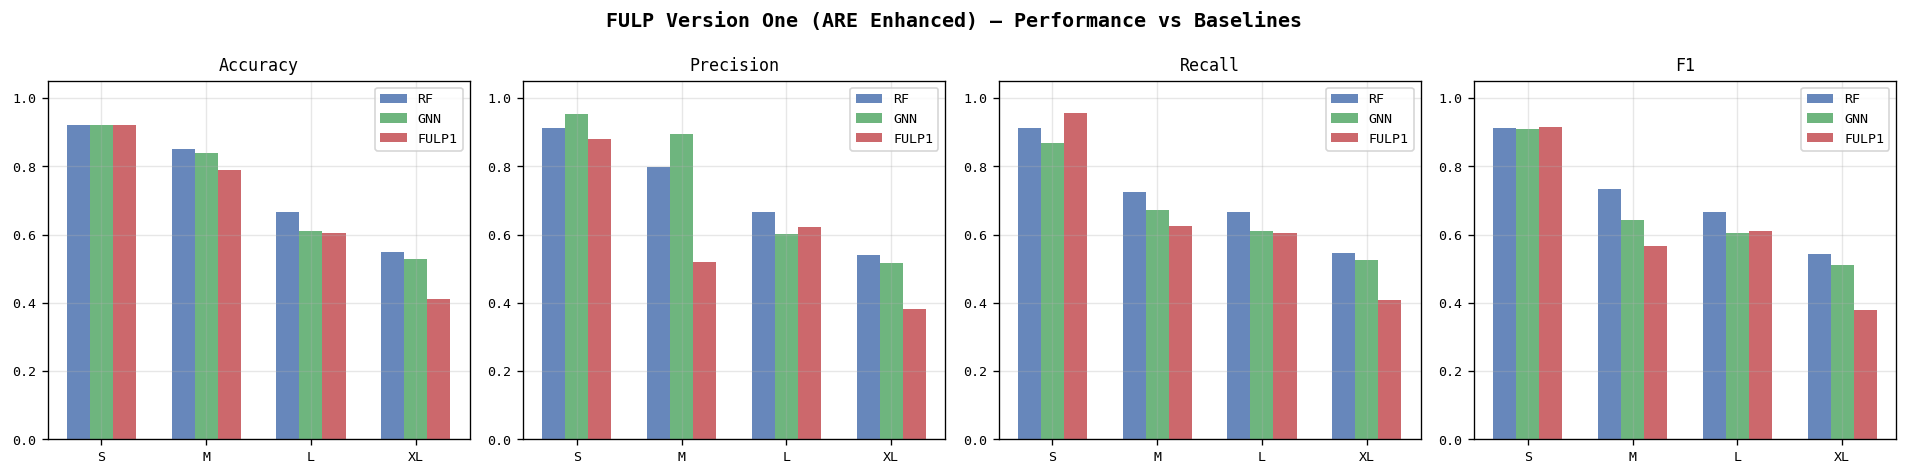

In [35]:
# ── Cell 13: Accuracy Comparison ────────────────────────────────────────────
metrics=['accuracy','precision','recall','f1']; models=['RF','GNN','FULP1']
x=np.arange(len(tiers)); w=0.22
fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('FULP Version One (ARE Enhanced) — Performance vs Baselines',fontweight='bold')
for ax,metric in zip(axes,metrics):
    for i,model in enumerate(models):
        vals=[RESULTS[t][model.lower()][metric] for t in tiers]
        ax.bar(x+(i-1)*w,vals,w,label=model,color=MODEL_COLORS[model],alpha=0.85)
    ax.set_title(metric.capitalize()); ax.set_xticks(x); ax.set_xticklabels(tiers)
    ax.set_ylim(0,1.05); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_accuracy.png'),bbox_inches='tight'); plt.show()


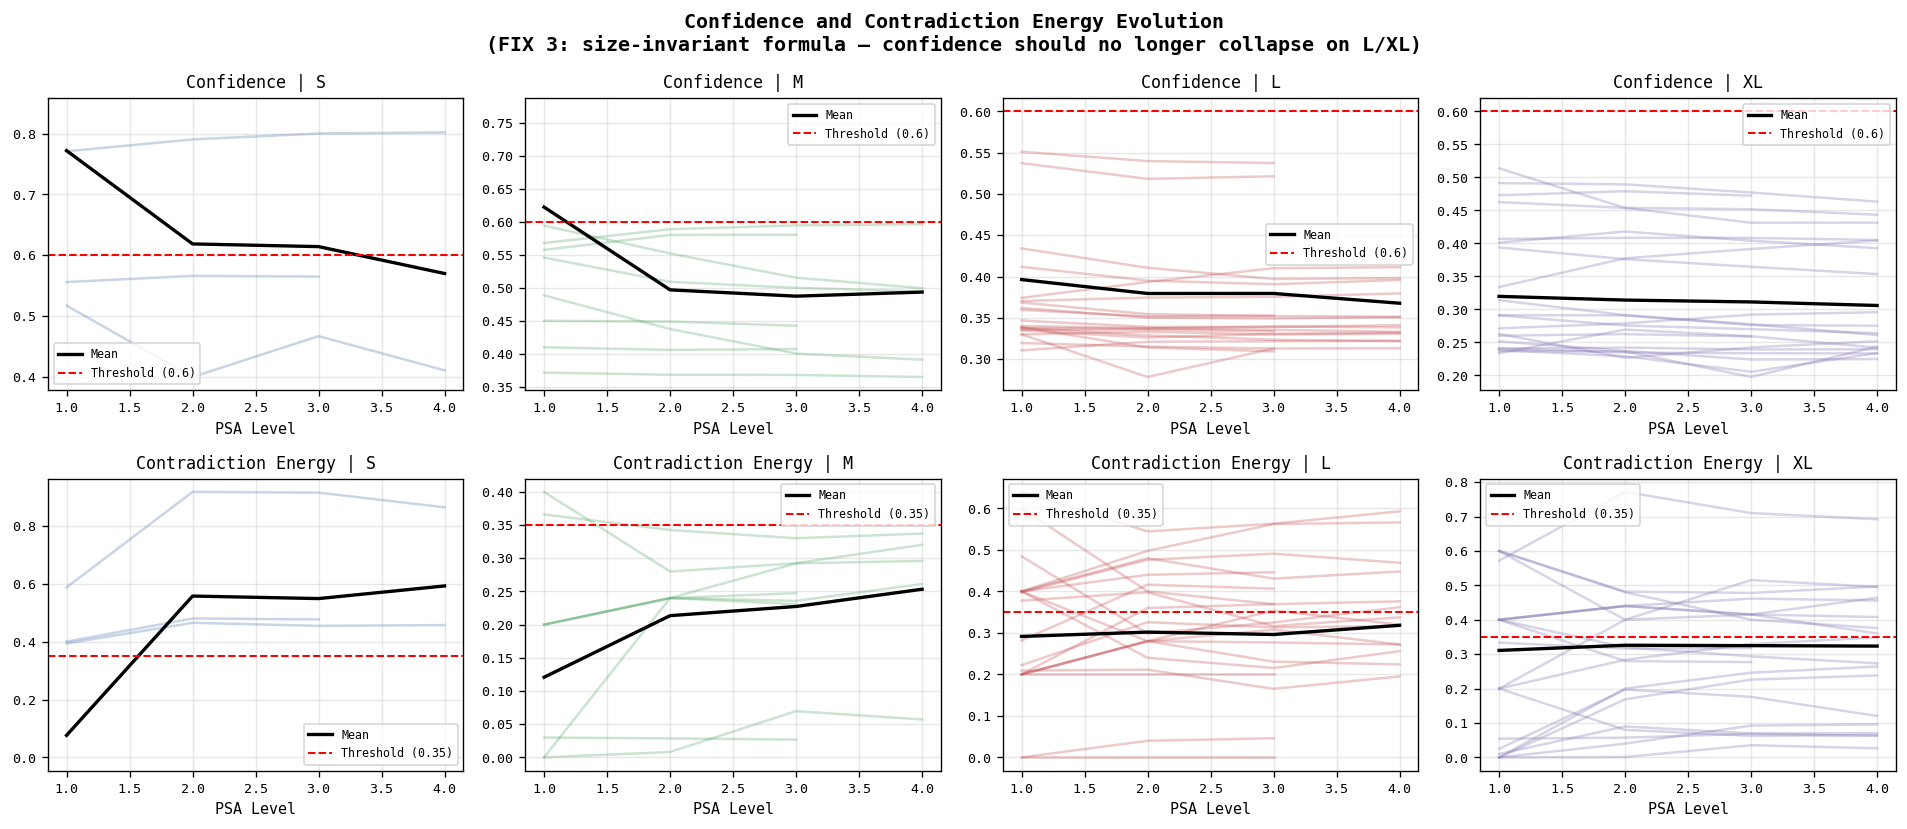

In [36]:
# ── Cell 14: Confidence & Contradiction Evolution ────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,7))
fig.suptitle('Confidence and Contradiction Energy Evolution\n'
             '(FIX 3: size-invariant formula — confidence should no longer collapse on L/XL)',
             fontweight='bold')
for ci,tier in enumerate(tiers):
    logs=RESULTS[tier]['all_logs'][:20]; all_logs=RESULTS[tier]['all_logs']
    max_len=max((len(lg['confidence_history']) for lg in all_logs if lg['confidence_history']),default=1)
    for log in logs:
        if log['confidence_history']:
            axes[0,ci].plot(range(1,len(log['confidence_history'])+1),log['confidence_history'],alpha=0.3,color=TIER_COLORS[tier])
        if log['contradiction_history']:
            axes[1,ci].plot(range(1,len(log['contradiction_history'])+1),log['contradiction_history'],alpha=0.3,color=TIER_COLORS[tier])
    for ri,(key,thresh,label) in enumerate([
            ('confidence_history',CONF_ACCEPT,'Confidence'),
            ('contradiction_history',CONT_ACCEPT,'Contradiction Energy')]):
        arr=np.full((len(all_logs),max_len),np.nan)
        for i,lg in enumerate(all_logs):
            h=lg[key]; arr[i,:len(h)]=h
        mean_h=np.nanmean(arr,axis=0)
        axes[ri,ci].plot(range(1,max_len+1),mean_h,color='black',lw=2,label='Mean')
        axes[ri,ci].axhline(thresh,color='red',linestyle='--',lw=1.2,label=f'Threshold ({thresh})')
        axes[ri,ci].set_title(f'{label} | {tier}'); axes[ri,ci].set_xlabel('PSA Level'); axes[ri,ci].legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_confidence.png'),bbox_inches='tight'); plt.show()


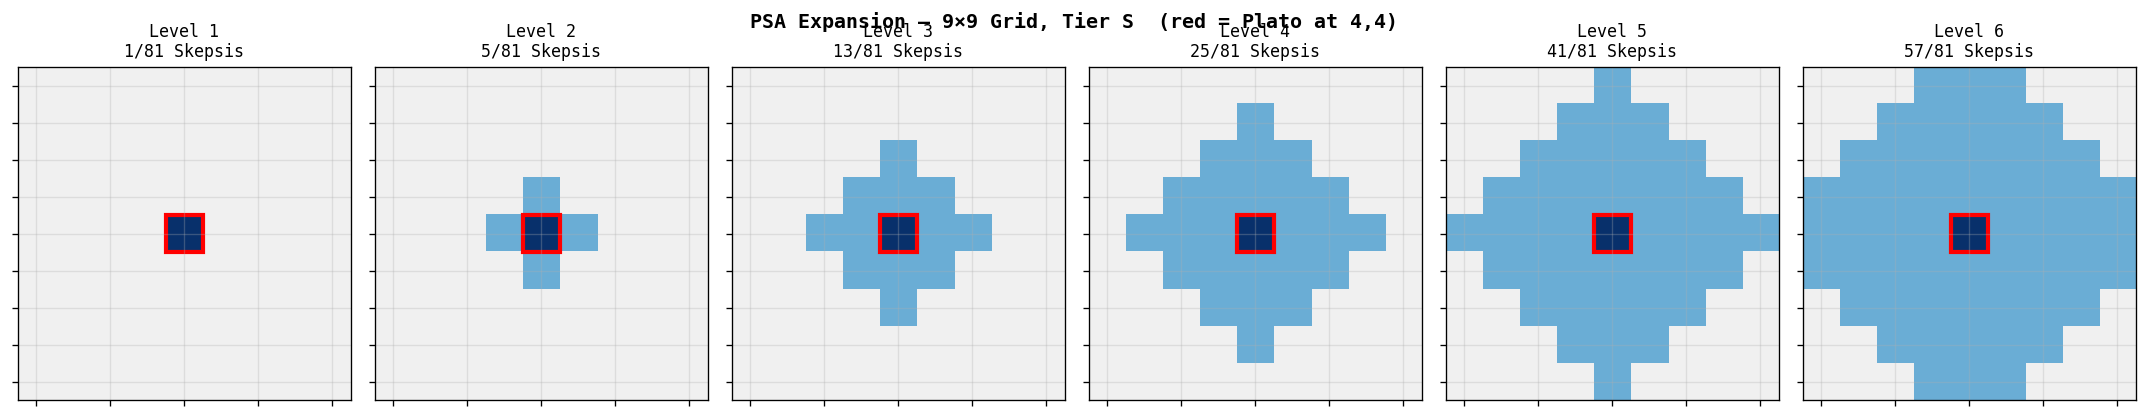

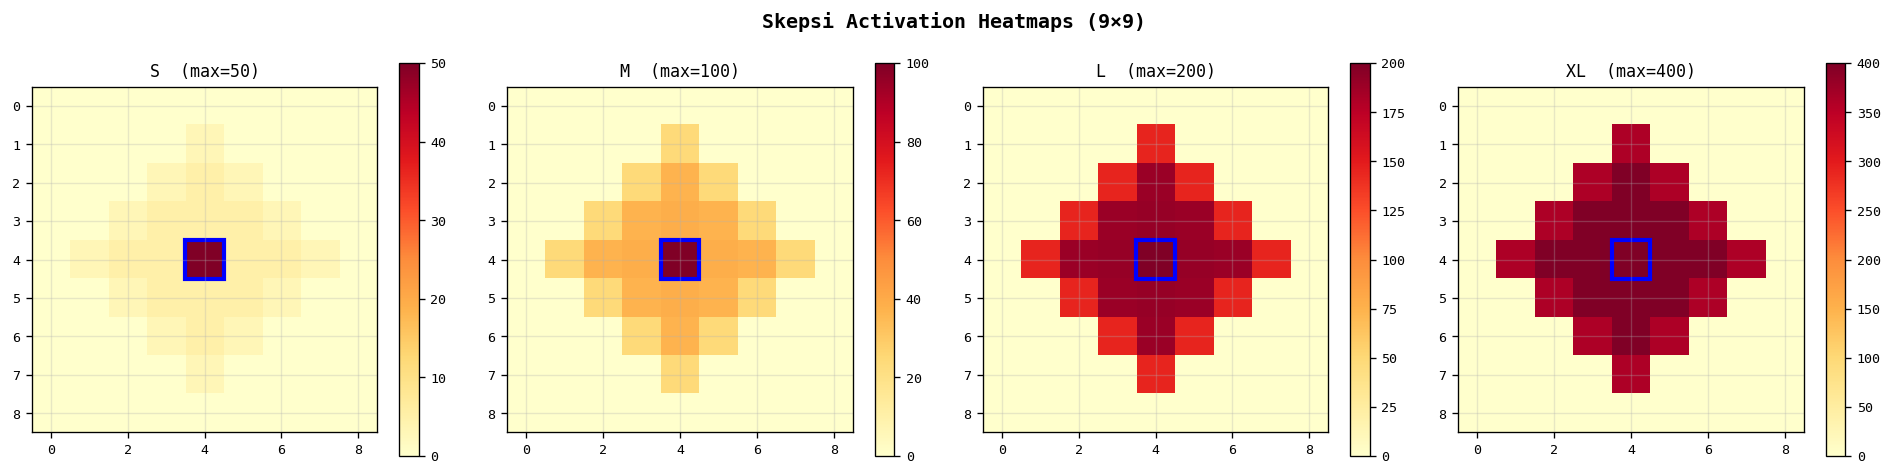

In [37]:
# ── Cell 15: PSA Expansion and Activation Heatmaps ──────────────────────────
enc_s=RESULTS['S']['enc']; H,W=enc_s.grid_h,enc_s.grid_w; cr,cc=enc_s.center
cmap_psa=LinearSegmentedColormap.from_list('psa',['#f0f0f0','#6baed6','#08306b'])

# PSA levels 1–6 (showing how expansion fills the 9×9 grid)
n_panels=6
fig,axes=plt.subplots(1,n_panels,figsize=(3*n_panels,3.5))
fig.suptitle(f'PSA Expansion — 9×9 Grid, Tier S  (red = Plato at {cr},{cc})',fontweight='bold')
for lv_idx,ax in enumerate(axes):
    level=lv_idx+1; active=set(_vn_up_to(cr,cc,level-1,H,W))
    gi=np.zeros((H,W))
    for (r,c) in active: gi[r,c]=1.0
    gi[cr,cc]=2.0
    ax.imshow(gi,cmap=cmap_psa,vmin=0,vmax=2)
    ax.set_title(f'Level {level}\n{len(active)}/{H*W} Skepsis')
    ax.tick_params(labelbottom=False,labelleft=False)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2.5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_psa.png'),bbox_inches='tight'); plt.show()

fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('Skepsi Activation Heatmaps (9×9)',fontweight='bold')
for ax,tier in zip(axes,tiers):
    hm=RESULTS[tier]['heatmap']; enc=RESULTS[tier]['enc']; cr2,cc2=enc.center
    im=ax.imshow(hm,cmap='YlOrRd'); plt.colorbar(im,ax=ax)
    ax.set_title(f'{tier}  (max={hm.max()})')
    ax.add_patch(plt.Rectangle((cc2-0.5,cr2-0.5),1,1,fill=False,edgecolor='blue',lw=2.5,label='Plato'))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_heatmaps.png'),bbox_inches='tight'); plt.show()


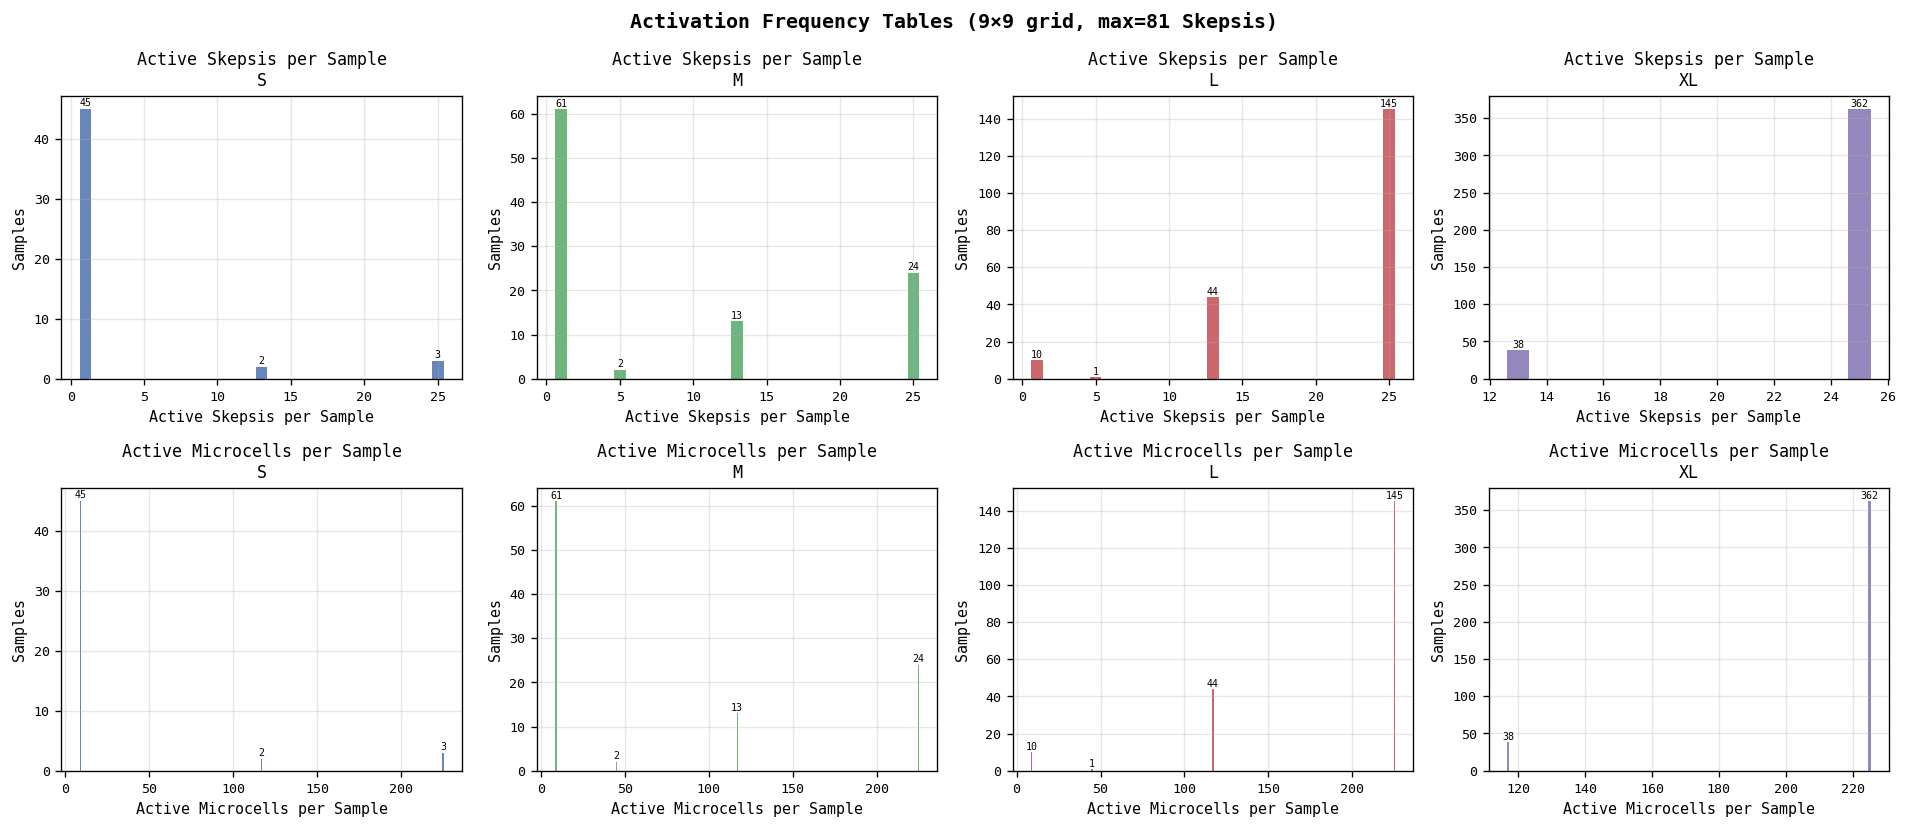

In [38]:
# ── Cell 16: Frequency Tables ────────────────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,7))
fig.suptitle('Activation Frequency Tables (9×9 grid, max=81 Skepsis)',fontweight='bold')
for ci,tier in enumerate(tiers):
    freq=RESULTS[tier]['freq_tabs']
    for ri,(key,label) in enumerate([
            ('skepsi_activation_counts','Active Skepsis per Sample'),
            ('microcell_activation_counts','Active Microcells per Sample')]):
        ax=axes[ri,ci]; cnts=freq[key]; xs,ys=list(cnts.keys()),list(cnts.values())
        ax.bar(xs,ys,color=TIER_COLORS[tier],alpha=0.85)
        ax.set_title(f'{label}\n{tier}'); ax.set_xlabel(label); ax.set_ylabel('Samples')
        for x2,y in zip(xs,ys): ax.text(x2,y+0.2,str(y),ha='center',va='bottom',fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_freq.png'),bbox_inches='tight'); plt.show()


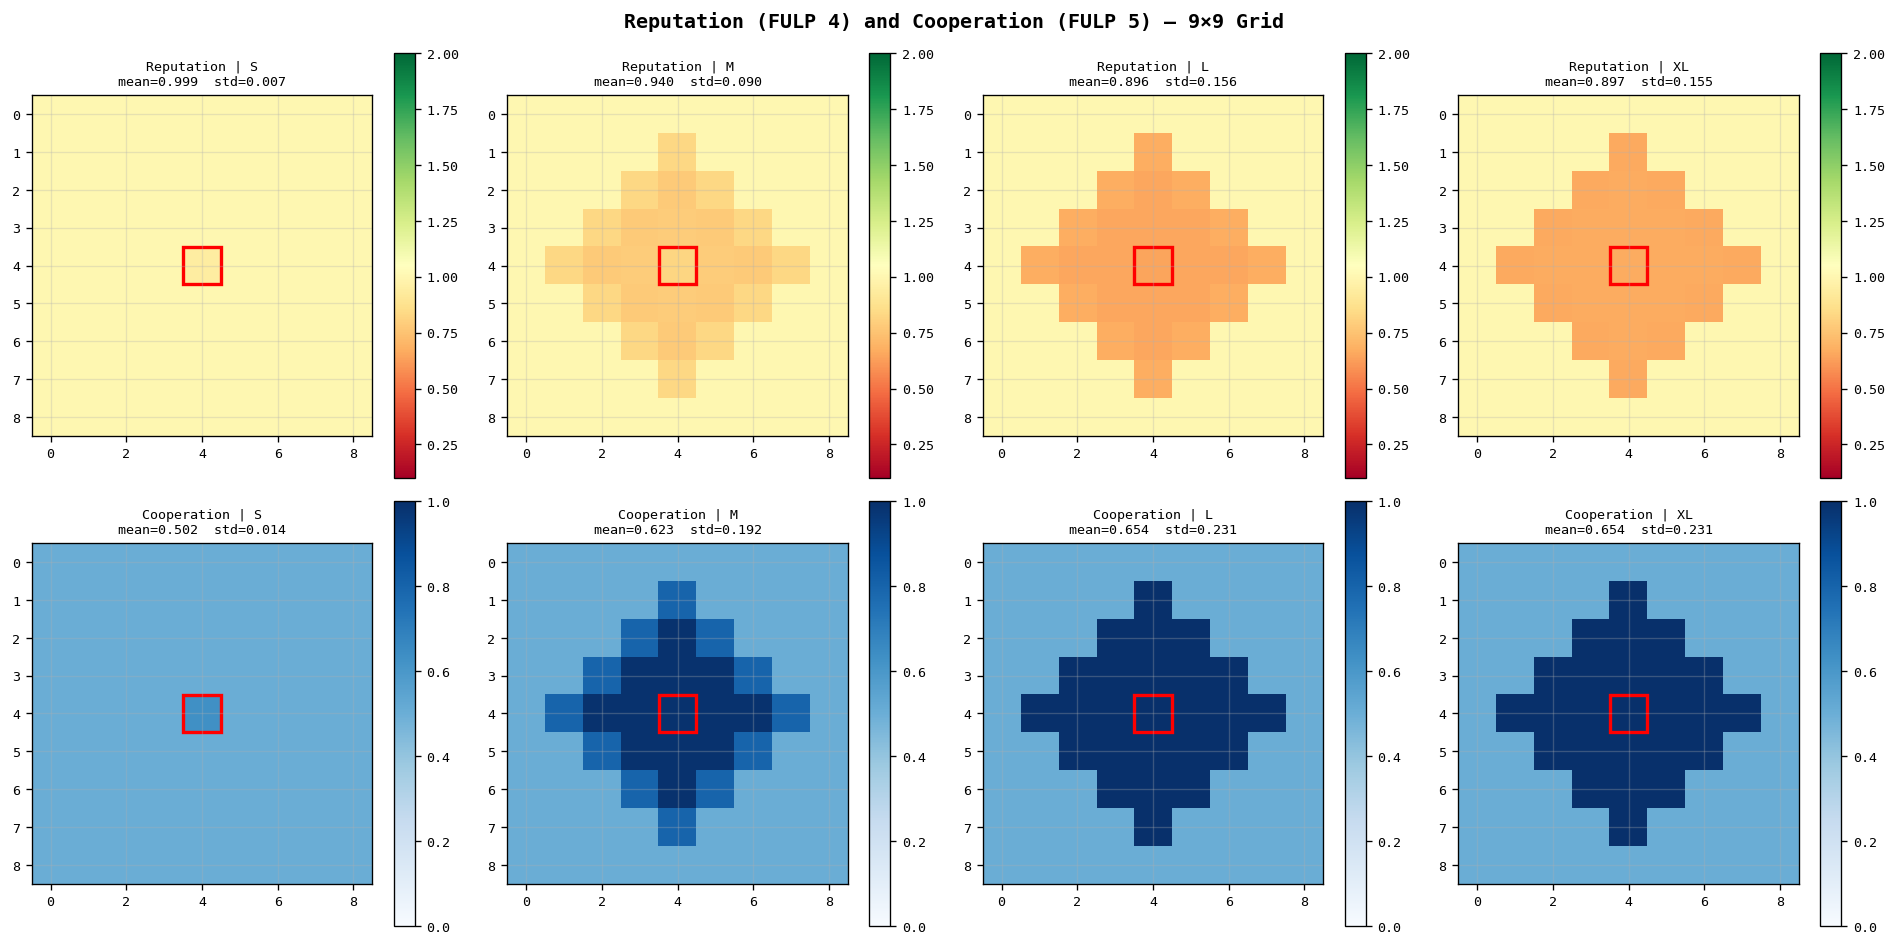

In [39]:
# ── Cell 17: Reputation and Cooperation Heatmaps ────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,8))
fig.suptitle('Reputation (FULP 4) and Cooperation (FULP 5) — 9×9 Grid',fontweight='bold')
for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center
    for ri,(key,title,cmap,vmin,vmax) in enumerate([
            ('rep_heatmap', 'Reputation',  'RdYlGn',REP_MIN,REP_MAX),
            ('coop_heatmap','Cooperation', 'Blues',  0,1)]):
        ax=axes[ri,ci]; hm=RESULTS[tier][key]
        im=ax.imshow(hm,cmap=cmap,vmin=vmin,vmax=vmax)
        plt.colorbar(im,ax=ax)
        ax.set_title(f'{title} | {tier}\nmean={hm.mean():.3f}  std={hm.std():.3f}',fontsize=8)
        ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_rep_coop.png'),bbox_inches='tight'); plt.show()


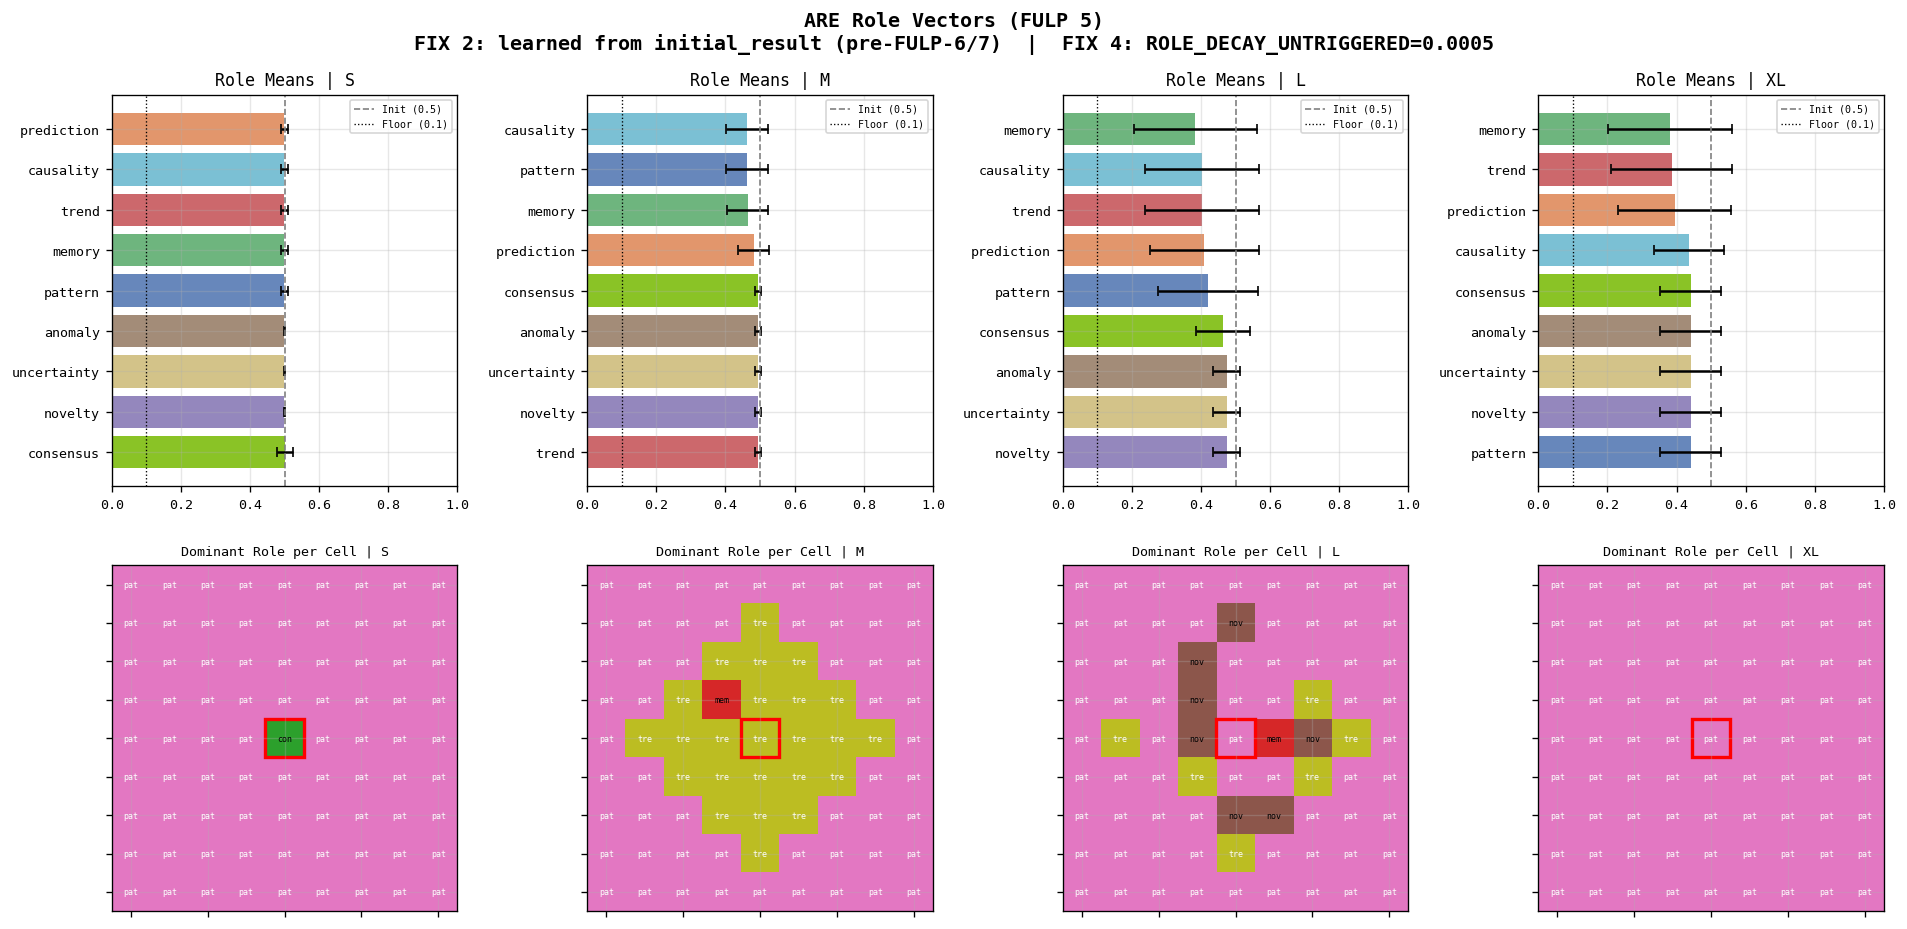


── ARE Sanity Check ────────────────────────────────────────────────
  Tier   Rep mean    Rep std    Coop mean    Top role        Top mean
  ------------------------------------------------------------
  S      0.9992      0.0067     0.5016       consensus       0.5026
  M      0.9403      0.0905     0.6231       trend           0.4948
  L      0.8957      0.1562     0.6543       novelty         0.4740
  XL     0.8967      0.1547     0.6543       pattern         0.4411

  Tier   Dominant role counts
  S      {'pattern': 80, 'consensus': 1}
  M      {'pattern': 56, 'trend': 24, 'memory': 1}
  L      {'pattern': 67, 'novelty': 7, 'trend': 6, 'memory': 1}
  XL     {'pattern': 81}


In [40]:
# ── Cell 18: ARE Role Vector Analysis ───────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,8))
fig.suptitle('ARE Role Vectors (FULP 5)\n'
             'FIX 2: learned from initial_result (pre-FULP-6/7)  |  '
             'FIX 4: ROLE_DECAY_UNTRIGGERED=0.0005',fontweight='bold')

for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center
    rv_means=enc.role_vector_mean(); rv_stds=enc.role_vector_std()

    ax=axes[0,ci]
    roles_sorted=sorted(rv_means,key=rv_means.get,reverse=True)
    means=[rv_means[r] for r in roles_sorted]; stds=[rv_stds[r] for r in roles_sorted]
    colors=[ROLE_COLORS[r] for r in roles_sorted]
    ax.barh(roles_sorted,means,xerr=stds,color=colors,alpha=0.85,capsize=3)
    ax.axvline(0.5,color='grey',linestyle='--',lw=1,label='Init (0.5)')
    ax.axvline(ROLE_MIN,color='black',linestyle=':',lw=0.8,label=f'Floor ({ROLE_MIN})')
    ax.set_title(f'Role Means | {tier}'); ax.set_xlim(0,1); ax.legend(fontsize=6)

    ax=axes[1,ci]
    dom_grid=enc.dominant_role_grid()
    role_to_int={r:i for i,r in enumerate(sorted(ROLE_COLORS))}
    dom_matrix=np.array([[role_to_int[dom_grid[r][c]] for c in range(enc.grid_w)]
                          for r in range(enc.grid_h)])
    cmap_roles=plt.cm.get_cmap('tab10',len(ROLE_COLORS))
    ax.imshow(dom_matrix,cmap=cmap_roles,vmin=0,vmax=len(ROLE_COLORS)-1)
    ax.set_title(f'Dominant Role per Cell | {tier}',fontsize=8)
    for r in range(enc.grid_h):
        for c in range(enc.grid_w):
            dom=dom_grid[r][c]
            ax.text(c,r,dom[:3],ha='center',va='center',fontsize=5,
                    color='white' if role_to_int[dom]>4 else 'black')
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_roles.png'),bbox_inches='tight'); plt.show()

print('\n── ARE Sanity Check ────────────────────────────────────────────────')
print(f'  {"Tier":<5}  {"Rep mean":<10}  {"Rep std":<9}  {"Coop mean":<11}  {"Top role":<14}  {"Top mean"}')
print('  '+'-'*60)
for tier in tiers:
    f=RESULTS[tier]['fulp1']
    top=max(f['role_means'],key=f['role_means'].get)
    print(f'  {tier:<5}  {f["rep_mean"]:<10.4f}  {f["rep_std"]:<9.4f}  '
          f'{f["coop_mean"]:<11.4f}  {top:<14}  {f["role_means"][top]:.4f}')
print()
print(f'  {"Tier":<5}  Dominant role counts')
for tier in tiers:
    print(f'  {tier:<5}  {dict(RESULTS[tier]["fulp1"]["dominant_role_counts"])}')


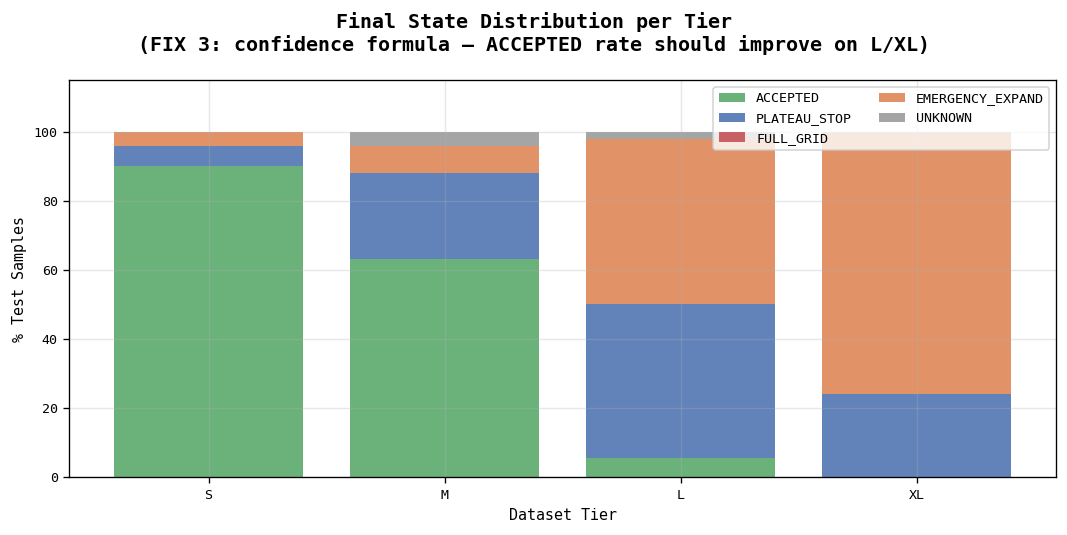

In [41]:
# ── Cell 19: State Transition Summary ───────────────────────────────────────
states=['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND','UNKNOWN']
state_colors={'ACCEPTED':'#55a868','PLATEAU_STOP':'#4c72b0','FULL_GRID':'#c44e52',
              'EMERGENCY_EXPAND':'#dd8452','UNKNOWN':'#999999'}
fig,ax=plt.subplots(figsize=(9,4.5))
fig.suptitle('Final State Distribution per Tier\n'
             '(FIX 3: confidence formula — ACCEPTED rate should improve on L/XL)',fontweight='bold')
x=np.arange(len(tiers)); bottoms=np.zeros(len(tiers))
n_samples=[RESULTS[t]['n_test'] for t in tiers]
for state in states:
    vals=[RESULTS[t]['fulp1'].get('state_counts',{}).get(state,0)/n*100 for t,n in zip(tiers,n_samples)]
    ax.bar(x,vals,bottom=bottoms,label=state,color=state_colors[state],alpha=0.88)
    bottoms+=np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(tiers)
ax.set_xlabel('Dataset Tier'); ax.set_ylabel('% Test Samples'); ax.set_ylim(0,115)
ax.legend(loc='upper right',ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_states.png'),bbox_inches='tight'); plt.show()


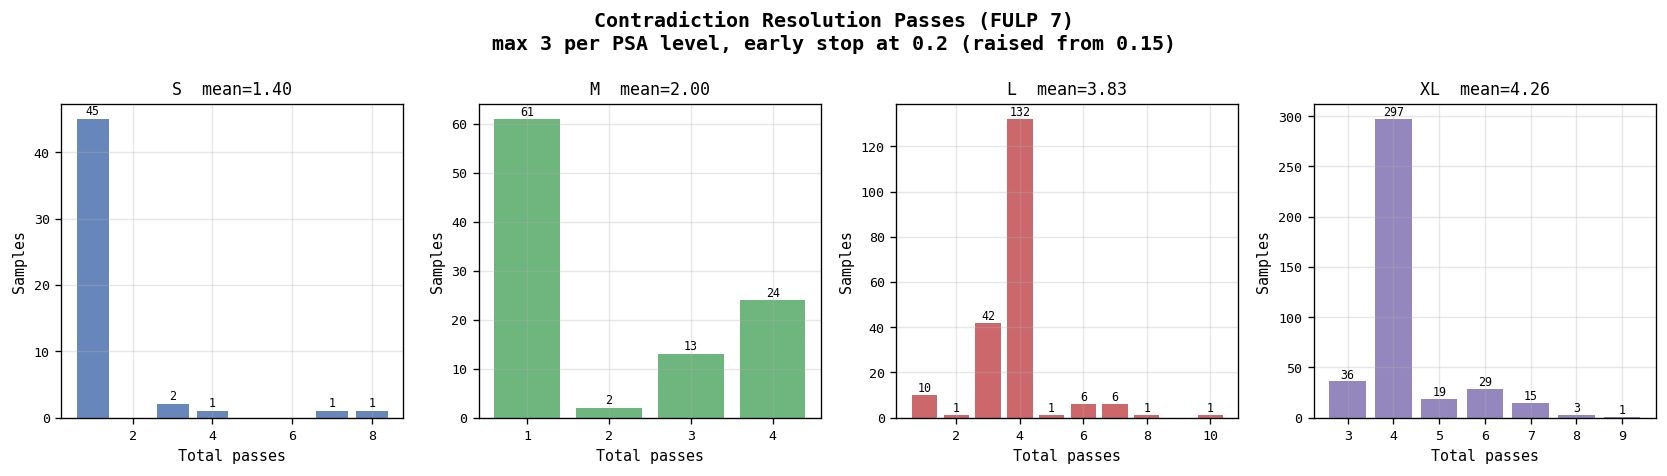

In [42]:
# ── Cell 20: Contradiction Resolution Passes ────────────────────────────────
fig,axes=plt.subplots(1,4,figsize=(14,4))
fig.suptitle(f'Contradiction Resolution Passes (FULP 7)\n'
             f'max {MAX_CONTRADICTION_PASSES} per PSA level, '
             f'early stop at {EARLY_STOP_CONTRADICTION} (raised from 0.15)',fontweight='bold')
for ax,tier in zip(axes,tiers):
    passes=[lg.get('contradiction_passes',0) for lg in RESULTS[tier]['all_logs']]
    cnts=Counter(passes); xs,ys=sorted(cnts.keys()),[cnts[k] for k in sorted(cnts.keys())]
    ax.bar(xs,ys,color=TIER_COLORS[tier],alpha=0.85)
    ax.set_title(f'{tier}  mean={np.mean(passes):.2f}')
    ax.set_xlabel('Total passes'); ax.set_ylabel('Samples')
    for x2,y in zip(xs,ys): ax.text(x2,y+0.2,str(y),ha='center',va='bottom',fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_cont_passes.png'),bbox_inches='tight'); plt.show()


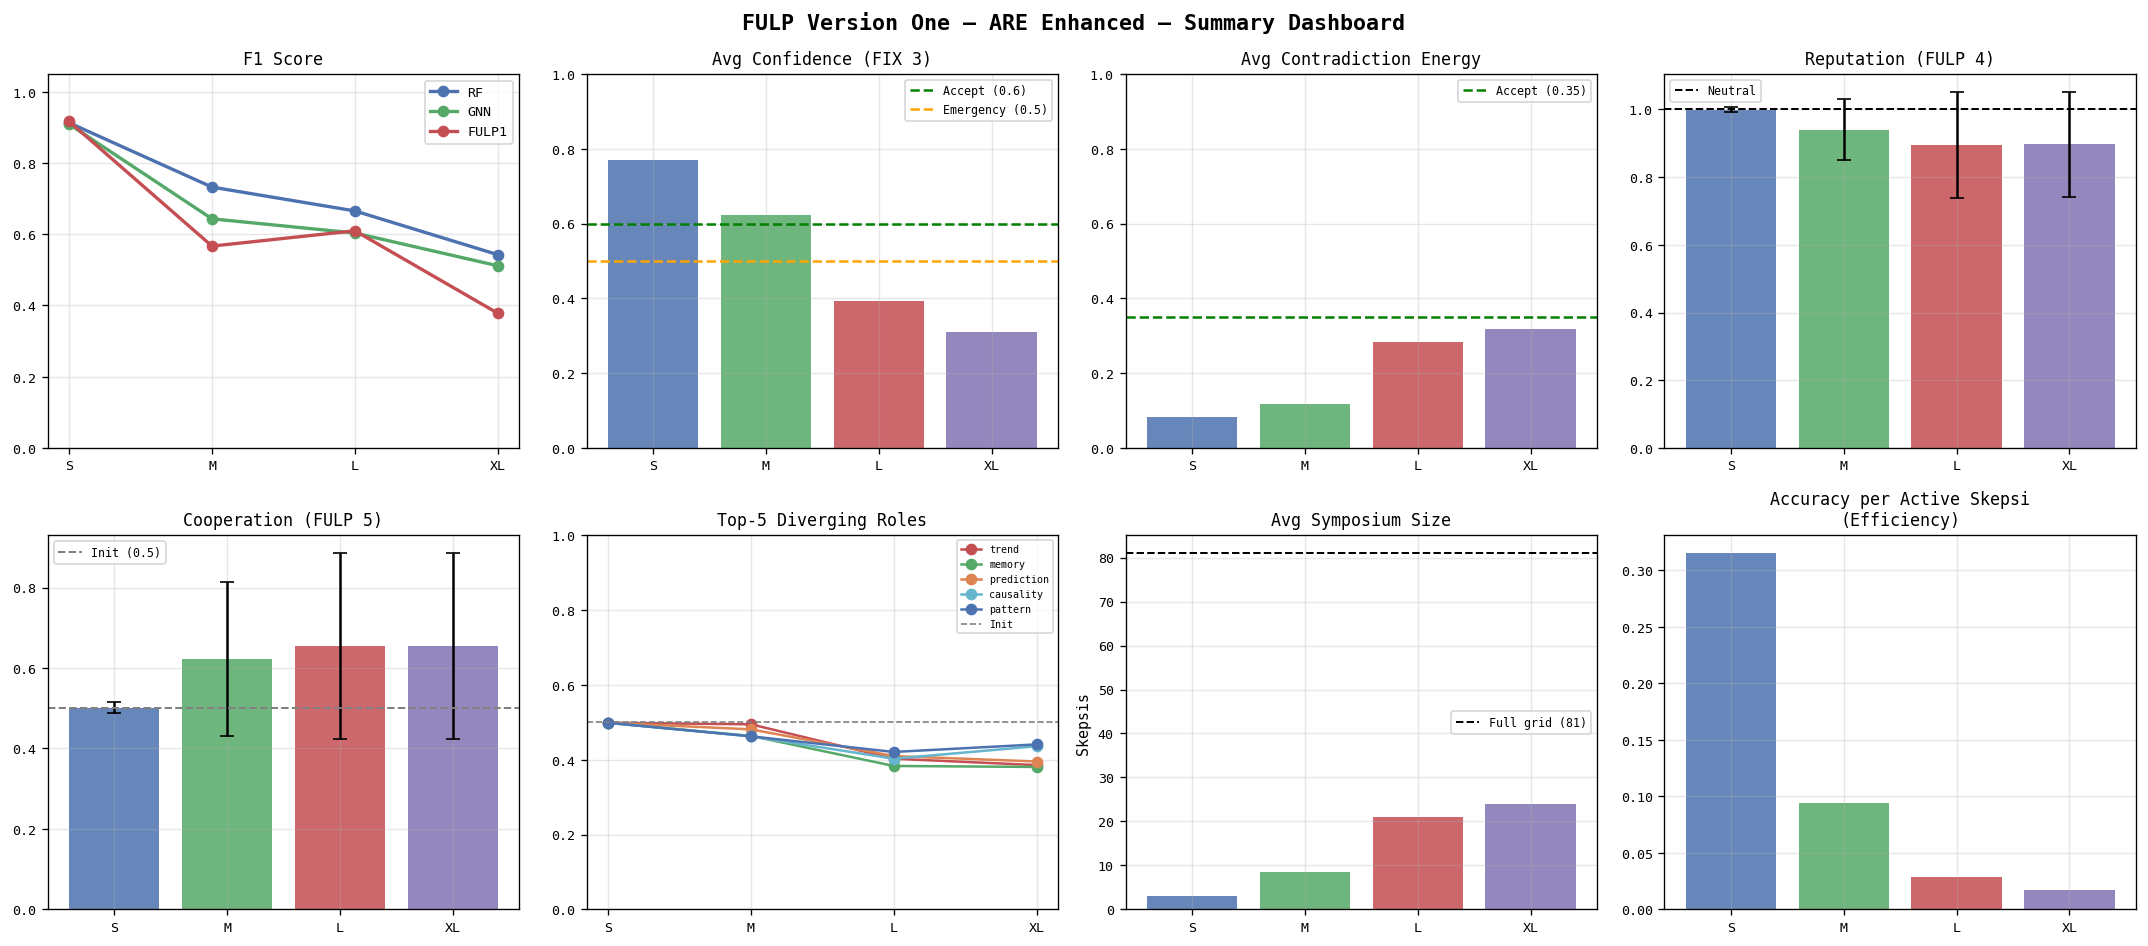

In [43]:
# ── Cell 21: Summary Dashboard ──────────────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(18,8))
fig.suptitle('FULP Version One — ARE Enhanced — Summary Dashboard',fontweight='bold',fontsize=13)

ax=axes[0,0]
for model,col in MODEL_COLORS.items():
    vals=[RESULTS[t][model.lower()]['f1'] for t in tiers]
    ax.plot(tiers,vals,'o-',color=col,label=model,lw=2)
ax.set_title('F1 Score'); ax.set_ylim(0,1.05); ax.legend()

ax=axes[0,1]
confs=[RESULTS[t]['fulp1']['avg_confidence'] for t in tiers]
ax.bar(tiers,confs,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(CONF_ACCEPT,color='green',linestyle='--',lw=1.5,label=f'Accept ({CONF_ACCEPT})')
ax.axhline(CONF_EMERGENCY,color='orange',linestyle='--',lw=1.5,label=f'Emergency ({CONF_EMERGENCY})')
ax.set_title('Avg Confidence (FIX 3)'); ax.set_ylim(0,1); ax.legend(fontsize=7)

ax=axes[0,2]
conts=[RESULTS[t]['fulp1']['avg_contradiction'] for t in tiers]
ax.bar(tiers,conts,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(CONT_ACCEPT,color='green',linestyle='--',lw=1.5,label=f'Accept ({CONT_ACCEPT})')
ax.set_title('Avg Contradiction Energy'); ax.set_ylim(0,1); ax.legend(fontsize=7)

ax=axes[0,3]
rep_means=[RESULTS[t]['fulp1']['rep_mean'] for t in tiers]
rep_stds =[RESULTS[t]['fulp1']['rep_std']  for t in tiers]
ax.bar(tiers,rep_means,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.errorbar(tiers,rep_means,rep_stds,fmt='none',color='black',capsize=4,lw=1.5)
ax.axhline(1.0,color='black',linestyle='--',lw=1.2,label='Neutral')
ax.set_title('Reputation (FULP 4)'); ax.legend(fontsize=7)

ax=axes[1,0]
coop_means=[RESULTS[t]['fulp1']['coop_mean'] for t in tiers]
coop_stds =[RESULTS[t]['fulp1']['coop_std']  for t in tiers]
ax.bar(tiers,coop_means,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.errorbar(tiers,coop_means,coop_stds,fmt='none',color='black',capsize=4,lw=1.5)
ax.axhline(0.5,color='grey',linestyle='--',lw=1.2,label='Init (0.5)')
ax.set_title('Cooperation (FULP 5)'); ax.legend(fontsize=7)

ax=axes[1,1]
all_rv_means={role:[RESULTS[t]['fulp1']['role_means'][role] for t in tiers] for role in ALL_ROLES}
sorted_roles=sorted(ALL_ROLES,key=lambda r:np.std([RESULTS[t]['fulp1']['role_means'][r] for t in tiers]),reverse=True)
for role in sorted_roles[:5]:
    ax.plot(tiers,all_rv_means[role],'o-',label=role,color=ROLE_COLORS[role],lw=1.5)
ax.axhline(0.5,color='grey',linestyle='--',lw=1,label='Init')
ax.set_title('Top-5 Diverging Roles'); ax.set_ylim(0,1); ax.legend(fontsize=6)

ax=axes[1,2]
sym=[RESULTS[t]['fulp1']['avg_symposium_size'] for t in tiers]
ax.bar(tiers,sym,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(GRID_H*GRID_W,color='black',linestyle='--',lw=1.2,label=f'Full grid ({GRID_H*GRID_W})')
ax.set_title('Avg Symposium Size'); ax.set_ylabel('Skepsis'); ax.legend(fontsize=7)

ax=axes[1,3]
eff=[RESULTS[t]['fulp1']['accuracy_per_skepsi'] for t in tiers]
ax.bar(tiers,eff,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.set_title('Accuracy per Active Skepsi\n(Efficiency)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fulp1_enh_dashboard.png'),bbox_inches='tight'); plt.show()


In [44]:
# ── Cell 22: Final Summary ───────────────────────────────────────────────────
print('\nFULPs — FULP Version One (ARE Enhanced) — Final Summary')
print('='*76)
fmt='{:<8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>9}'
print(fmt.format('Tier','RF Acc','GNN Acc','ENH Acc','RF F1','GNN F1','ENH F1','Avg Conf'))
print('-'*76)
for tier in tiers:
    r=RESULTS[tier]
    print(fmt.format(tier,
        f'{r["rf"]["accuracy"]:.4f}',f'{r["gnn"]["accuracy"]:.4f}',f'{r["fulp1"]["accuracy"]:.4f}',
        f'{r["rf"]["f1"]:.4f}',f'{r["gnn"]["f1"]:.4f}',f'{r["fulp1"]["f1"]:.4f}',
        f'{r["fulp1"]["avg_confidence"]:.4f}'))
print('='*76)

print('\nFour targeted fixes applied:')
print(f'  FIX 1: Grid {GRID_H}×{GRID_W}={GRID_H*GRID_W} Skepsis  |  MAX_PSA_LEVELS={MAX_PSA_LEVELS}')
print( '  FIX 2: initial_result snapshot — FULP 5 learns from pre-FULP-6/7 prediction')
print( '  FIX 3: size-invariant confidence = max(fused) × (0.5 + 0.5 × agreement_rate)')
print(f'  FIX 4: ROLE_DECAY_UNTRIGGERED={ROLE_DECAY_UNTRIGGERED}  EARLY_STOP_CONTRADICTION={EARLY_STOP_CONTRADICTION}')

print("""
Expected improvements vs ARE Edition:

  avg_confidence on L/XL:
    Before FIX 3: ~0.24 / ~0.14  (collapsing due to 1/N penalty)
    After  FIX 3: should remain above CONF_EMERGENCY on most samples

  ACCEPTED rate on L/XL:
    Before: 40/400 = 10% accepted on L
    After: should rise as confidence stays in healthy range

  Role vector divergence:
    Before: all roles drifting to ~0.38 on XL
    After FIX 2+4: roles should maintain values above 0.4
                   and show wider std (>0.05) as specialization develops

  Dominant role variety:
    Before: pattern dominated everywhere
    After FIX 2: credit attribution corrected, other roles should emerge
""")



FULPs — FULP Version One (ARE Enhanced) — Final Summary
Tier        RF Acc   GNN Acc   ENH Acc     RF F1    GNN F1    ENH F1   Avg Conf
----------------------------------------------------------------------------
S           0.9200    0.9200    0.9200    0.9130    0.9091    0.9167     0.7704
M           0.8500    0.8400    0.7900    0.7324    0.6433    0.5667     0.6241
L           0.6650    0.6100    0.6050    0.6655    0.6035    0.6098     0.3934
XL          0.5475    0.5275    0.4100    0.5426    0.5114    0.3781     0.3103

Four targeted fixes applied:
  FIX 1: Grid 9×9=81 Skepsis  |  MAX_PSA_LEVELS=4
  FIX 2: initial_result snapshot — FULP 5 learns from pre-FULP-6/7 prediction
  FIX 3: size-invariant confidence = max(fused) × (0.5 + 0.5 × agreement_rate)
  FIX 4: ROLE_DECAY_UNTRIGGERED=0.0005  EARLY_STOP_CONTRADICTION=0.2

Expected improvements vs ARE Edition:

  avg_confidence on L/XL:
    Before FIX 3: ~0.24 / ~0.14  (collapsing due to 1/N penalty)
    After  FIX 3: should rema